# Role 1 — Data Engineering & EDA
### ICCIT 2026 — Trust Under Dialect Shift: Calibration and Selective Classification for Bangla Hate Speech Detection Across Regional Dialects

**Objective.** Produce the clean, split, aligned datasets that Roles 2–4 depend on:
- `train.csv`, `val.csv`, `test_standard.csv` (from BD-SHS)
- `test_dialect_chittagong.csv`, `test_dialect_noakhali.csv`, `test_dialect_barishal.csv` (from BIDWESH, aligned to BD-SHS base instances where possible)
- An EDA report (class balance, text length, vocabulary overlap)
- `data_card.md` documenting preprocessing decisions

**Shared schema (must match exactly, see Part 1 §5 of the brief):**
`id, text, label, dialect` where `dialect ∈ {standard, chittagong, noakhali, barishal}`, `label ∈ {0,1}` (1 = hate).

**Run this on Kaggle** with a T4 (or even CPU-only — this notebook does no GPU work). `seed = 42` everywhere.

---
### Before you run this notebook — add the two datasets

1. **BD-SHS** — On the right sidebar in Kaggle: *Add Input → search "bdshs"* → add **`naurosromim/bdshs`**.
   (Note: the brief mentions `naurosromim/bengali-hate-speech-dataset` as a mirror — that is actually a *different*, smaller dataset (HS-BAN, ~30K rows). The real BD-SHS mirror with the pre-split `train/val/test.csv` used in the BD-SHS paper is **`naurosromim/bdshs`**. This notebook auto-detects whichever you attach, but `bdshs` is the correct one.)
2. **BIDWESH** — Mendeley Data does not expose a stable, unauthenticated direct-download link, so it can't be `wget`'d from inside a notebook. Instead:
   - Open https://data.mendeley.com/datasets/bpkrvf882k/1 → click **"Download All"** → you'll get a zip.
   - On Kaggle: *Add Input → Upload → New Dataset* → upload that zip (e.g. name it `bidwesh-dialect-hate-speech`) → attach it to this notebook.
   - This is a one-time step; after that the dataset lives under your Kaggle account and every teammate can reuse it (or you can make it public/shared with the team).

Once both are attached, run the cells below top to bottom.


## 1. Setup

In [ ]:
import os, re, json, glob, zipfile, hashlib, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 120)

WORK_DIR = Path("/kaggle/working")
OUT_DIR = WORK_DIR / "data" / "processed"
EDA_DIR = WORK_DIR / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)
EDA_DIR.mkdir(parents=True, exist_ok=True)

INPUT_DIR = Path("/kaggle/input")
print("Kaggle inputs found:", list(INPUT_DIR.iterdir()) if INPUT_DIR.exists() else "none (not running on Kaggle?)")


## 2. Locate the attached datasets

We search `/kaggle/input/*` for anything that looks like BD-SHS or BIDWESH by folder/file name, rather than
hardcoding a single exact path — Kaggle dataset slugs and internal filenames vary slightly between mirrors,
and this way the notebook doesn't break if you attach a slightly differently-named copy.


In [ ]:
from pathlib import Path

INPUT_DIR = Path("/kaggle/input/datasets/kmtahlilmahfuzfaruk")

print("Mounted Kaggle datasets:\n")

for p in INPUT_DIR.iterdir():
    print("📁", p.name)

    if p.is_dir():
        for f in p.rglob("*"):
            if f.is_file():
                print("   └──", f.relative_to(p))

In [ ]:
def find_candidate_dirs(keywords):
    '''Return kaggle-input subdirectories whose name matches any keyword (case-insensitive).'''
    if not INPUT_DIR.exists():
        return []
    hits = []
    for p in INPUT_DIR.iterdir():
        name = p.name.lower()
        if any(k in name for k in keywords):
            hits.append(p)
    return hits

bdshs_dirs = find_candidate_dirs(["bdshs", "bd-shs", "bengali-hate", "bengali_hate"])
bidwesh_dirs = find_candidate_dirs(["bidwesh", "dialect"])

print("BD-SHS candidate dirs:  ", bdshs_dirs)
print("BIDWESH candidate dirs: ", bidwesh_dirs)

def list_files(dirs, exts=(".csv", ".tsv", ".xlsx", ".xls", ".json", ".zip")):
    files = []
    for d in dirs:
        for p in d.rglob("*"):
            if p.suffix.lower() in exts:
                files.append(p)
    return files

bdshs_files = list_files(bdshs_dirs)
bidwesh_files = list_files(bidwesh_dirs)
print("\nBD-SHS files:")
for f in bdshs_files: print(" ", f)
print("\nBIDWESH files:")
for f in bidwesh_files: print(" ", f)

assert bdshs_files, "No BD-SHS files found under /kaggle/input. Add the 'naurosromim/bdshs' dataset and re-run."
assert bidwesh_files, "No BIDWESH files found under /kaggle/input. Upload the Mendeley zip as a Kaggle dataset and re-run."


## 3. Load BD-SHS (standard Bangla)

The official BD-SHS Kaggle mirror ships pre-split `train.csv` / `val.csv` / `test.csv`. We use that split
directly (rather than re-splitting from scratch) since it's the split the original paper's ~91% F1 benchmark
was measured against — this makes our "sanity check against the BD-SHS paper" in Role 2 meaningful.

If instead only a single combined file is found (some mirrors ship one CSV), we fall back to our own
stratified 80/10/10 split with `seed=42`.


In [ ]:
def load_any(path):
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() == ".tsv":
        return pd.read_csv(path, sep="\t")
    if path.suffix.lower() in (".xlsx", ".xls"):
        return pd.read_excel(path)
    if path.suffix.lower() == ".json":
        return pd.read_json(path, lines=path.stat().st_size > 0 and open(path, encoding="utf-8").readline().count("}") == 1)
    raise ValueError(f"Unhandled file type: {path}")

# Try to identify pre-split files by filename
split_files = {}
for f in bdshs_files:
    stem = f.stem.lower()
    if "train" in stem:
        split_files["train"] = f
    elif "val" in stem or "dev" in stem:
        split_files["val"] = f
    elif "test" in stem:
        split_files["test"] = f

print("Detected split files:", split_files)

if len(split_files) == 3:
    bdshs_raw = {k: load_any(v) for k, v in split_files.items()}
    presplit = True
else:
    # fall back: load the single largest CSV and split ourselves later
    biggest = max(bdshs_files, key=lambda p: p.stat().st_size)
    bdshs_raw = {"all": load_any(biggest)}
    presplit = False

for k, df in bdshs_raw.items():
    print(f"\n--- {k} : shape={df.shape} ---")
    print(df.columns.tolist())
    display(df.head(3))


## 4. Standardize the BD-SHS schema

BD-SHS's raw column names vary by mirror (commonly something like `sentence`/`text` and `hate`/`label`,
with labels sometimes stored as strings `HS`/`NH` per the paper's abbreviations). We auto-detect the text
and label columns from a candidate list and print what was picked — **check this output**, and adjust
`TEXT_COL_CANDIDATES` / `LABEL_COL_CANDIDATES` below manually if the auto-pick looks wrong for your mirror.


In [ ]:
for k, df in bdshs_raw.items():
    print(f"\n===== {k} =====")
    print("target:")
    print(df["target"].value_counts(dropna=False))

    print("\nhate speech:")
    print(df["hate speech"].value_counts(dropna=False))

    print("\ntype:")
    print(df["type"].value_counts(dropna=False))

In [ ]:
TEXT_COL_CANDIDATES = ["text", "sentence", "comment", "comments", "content", "body"]
LABEL_COL_CANDIDATES = ["label", "hate", "hate_speech", "category", "class", "target_label","hate speech"]

def pick_col(df, candidates):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in cols_lower:
            return cols_lower[cand]
    return None

def standardize_label(series):
    '''Map whatever label encoding is present to {0,1} with 1 = hate.'''
    if series.dtype == object:
        s = series.astype(str).str.strip().str.upper()
        mapping = {"HS": 1, "HATE": 1, "1": 1, "TRUE": 1,
                   "NH": 0, "NOT HATE": 0, "NON-HATE": 0, "NONHATE": 0, "0": 0, "FALSE": 0}
        mapped = s.map(mapping)
        if mapped.isna().any():
            print("WARNING: some labels did not map cleanly, unique raw values:", s.unique())
        return mapped.astype("Int64")
    else:
        return series.astype(int)

def standardize_bdshs(df):
    text_col = pick_col(df, TEXT_COL_CANDIDATES)
    label_col = pick_col(df, LABEL_COL_CANDIDATES)
    print("  -> text col:", text_col, "| label col:", label_col)
    assert text_col is not None, f"Could not auto-detect text column among {df.columns.tolist()}"
    assert label_col is not None, f"Could not auto-detect label column among {df.columns.tolist()}"
    out = pd.DataFrame({
        "text": df[text_col].astype(str),
        "label": standardize_label(df[label_col]),
    })
    return out

print("Standardizing columns:")
bdshs_std = {}
for k, df in bdshs_raw.items():
    print(f"[{k}]")
    bdshs_std[k] = standardize_bdshs(df)

for k, df in bdshs_std.items():
    print(k, df["label"].value_counts(dropna=False).to_dict())


## 5. Cleaning

Decisions made here (also written into `data_card.md` at the end):

- **Deduplicate** on exact normalized text (case/whitespace-insensitive).
- **Whitespace**: collapse repeated whitespace, strip leading/trailing.
- **URLs**: replaced with a `<URL>` placeholder token (URLs carry no hate-speech signal and are a common
  source of near-duplicate spam patterns).
- **@mentions**: replaced with a `<MENTION>` placeholder (removes usernames as a shortcut/confound feature
  while preserving the sentence structure).
- **Emoji: kept as-is.** We deliberately do NOT strip emoji — some emoji carry hateful meaning on their own
  (a well-documented pattern in Bangla/South-Asian social media hate speech), so stripping them could
  silently remove label-relevant signal. This is a documented, deliberate choice, not an oversight.
- Rows that become empty after cleaning are dropped.


In [ ]:
URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
MENTION_RE = re.compile(r"@\w+")
WS_RE = re.compile(r"\s+")

def clean_text(t):
    t = str(t)
    t = URL_RE.sub(" <URL> ", t)
    t = MENTION_RE.sub(" <MENTION> ", t)
    t = WS_RE.sub(" ", t).strip()
    return t

def clean_and_dedup(df, name=""):
    before = len(df)
    df = df.copy()
    df["text"] = df["text"].map(clean_text)
    df = df[df["text"].str.len() > 0]
    df = df[df["label"].notna()]
    df["label"] = df["label"].astype(int)
    dup_key = df["text"].str.lower().str.strip()
    n_dupes = dup_key.duplicated().sum()
    df = df[~dup_key.duplicated(keep="first")]
    after = len(df)
    print(f"[{name}] {before} -> {after} rows "
          f"(dropped {before - after}: {n_dupes} dupes + empties/NA-label)")
    return df.reset_index(drop=True)

bdshs_clean = {k: clean_and_dedup(df, k) for k, df in bdshs_std.items()}


## 6. Split (or respect the pre-existing split), stratified by label, seed=42


In [ ]:
from sklearn.model_selection import train_test_split

if presplit:
    train_df, val_df, test_df = bdshs_clean["train"], bdshs_clean["val"], bdshs_clean["test"]
else:
    all_df = bdshs_clean["all"]
    train_df, temp_df = train_test_split(
        all_df, test_size=0.20, random_state=SEED, stratify=all_df["label"]
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
    )

for name, df in [("train", train_df), ("val", val_df), ("test_standard", test_df)]:
    print(name, df.shape, "label balance:", df["label"].value_counts(normalize=True).round(3).to_dict())


## 7. Assign IDs and the shared schema, save standard-Bangla splits

`id` is a stable string built as `std_{row_index}` so it can be referenced later. Every processed file
gets the exact shared schema from Part 1 §5: `id, text, label, dialect`.


In [ ]:
def finalize(df, dialect, prefix):
    df = df.reset_index(drop=True).copy()
    df.insert(0, "id", [f"{prefix}_{i}" for i in range(len(df))])
    df["dialect"] = dialect
    return df[["id", "text", "label", "dialect"]]

train_final = finalize(train_df, "standard", "train")
val_final = finalize(val_df, "standard", "val")
test_standard_final = finalize(test_df, "standard", "teststd")

train_final.to_csv(OUT_DIR / "train.csv", index=False, encoding="utf-8")
val_final.to_csv(OUT_DIR / "val.csv", index=False, encoding="utf-8")
test_standard_final.to_csv(OUT_DIR / "test_standard.csv", index=False, encoding="utf-8")

print("Saved:")
for f in ["train.csv", "val.csv", "test_standard.csv"]:
    print(" ", OUT_DIR / f)
train_final.head()


## 8. Load BIDWESH (dialectal parallel test set)

BIDWESH is published as a **wide, parallel table**: one row = one base instance, with a column per dialect
(Standard Bangla / Chittagong / Noakhali / Barishal) plus `Type`, `Target`, and a hate-speech label — see
the paper's Table 3 (Fayaz et al., 2025). We melt this into the long format our shared schema needs (one
row per dialect instance), then try to align each row back to its BD-SHS standard-Bangla counterpart via
exact text match (BIDWESH doesn't ship a shared numeric ID with BD-SHS, so text-matching on the normalized
standard-Bangla column is the most reliable link we have).

If the file you uploaded is a `.zip`, we extract it first.


In [ ]:
# Extract any zip files
for f in list(bidwesh_files):
    if f.suffix.lower() == ".zip":
        extract_dir = f.parent / (f.stem + "_extracted")
        if not extract_dir.exists():
            with zipfile.ZipFile(f) as zf:
                zf.extractall(extract_dir)
        bidwesh_files.extend(list_files([extract_dir]))

bidwesh_files = [f for f in bidwesh_files if f.suffix.lower() != ".zip"]
print("BIDWESH data files after extraction:")
for f in bidwesh_files: print(" ", f)

biggest_bidwesh = max(bidwesh_files, key=lambda p: p.stat().st_size)
print("\nLoading:", biggest_bidwesh)
bidwesh_raw = load_any(biggest_bidwesh)
print(bidwesh_raw.shape)
print(bidwesh_raw.columns.tolist())
bidwesh_raw.head()


In [ ]:
bidwesh_dataset_file = [
    f for f in bidwesh_files
    if f.name.lower() == "bidwesh dataset.csv"
][0]

bidwesh_raw = pd.read_csv(bidwesh_dataset_file)

print("BIDWESH Dataset.csv columns:")
print(list(bidwesh_raw.columns))

print("\nShape:", bidwesh_raw.shape)

display(bidwesh_raw.head())

In [ ]:
# --- Column mapping: EDIT THIS if the auto-detected names below look wrong ---
# Print the actual columns and eyeball them before trusting the auto-detection.
print("Actual BIDWESH columns:", list(bidwesh_raw.columns))

def find_col(df, must_contain, exclude=()):
    for c in df.columns:
        cl = c.lower()
        if any(m in cl for m in must_contain) and not any(e in cl for e in exclude):
            return c
    return None

COLUMN_MAP = {
    "standard": "Standard Bangla",
    "chittagong": "Chittagong",
    "noakhali": "Noakhali",
    "barishal": "Barishal",
    "label": "hate speech",
    "type": "type",
    "target": "target",
}
print("\nAuto-detected COLUMN_MAP:")
for k, v in COLUMN_MAP.items():
    print(f"  {k:12s} -> {v}")

missing = [k for k, v in COLUMN_MAP.items() if v is None and k in ("standard", "chittagong", "noakhali", "barishal", "label")]
if missing:
    print("\n*** Could not auto-detect these required columns:", missing)
    print("*** Manually set COLUMN_MAP[...] to the correct column name from the list printed above, then re-run this cell.")


In [ ]:
print("Hate speech distribution:")
print(bidwesh_raw["hate speech"].value_counts(dropna=False))

print("\nTarget distribution:")
print(bidwesh_raw["target"].value_counts(dropna=False))

print("\nType distribution:")
print(bidwesh_raw["type"].value_counts(dropna=False))

In [ ]:
# Load Standard Bangla texts from the separate BIDWESH file
regional_file = [
    f for f in bidwesh_files
    if f.name.lower() == "regional translated texts.csv"
][0]

regional_raw = pd.read_csv(regional_file)

print("Regional columns:", regional_raw.columns.tolist())
print("Regional shape:", regional_raw.shape)
print("BIDWESH shape:", bidwesh_raw.shape)

assert "Standard Bangla" in regional_raw.columns, \
    "Standard Bangla column not found in Regional Translated Texts.csv"

assert len(regional_raw) == len(bidwesh_raw), \
    "BIDWESH Dataset.csv and Regional Translated Texts.csv have different row counts."

# Attach Standard Bangla to BIDWESH Dataset
regional_raw = regional_raw.reset_index(drop=True)
bidwesh_raw = bidwesh_raw.reset_index(drop=True)

bidwesh_raw["Standard Bangla"] = regional_raw["Standard Bangla"]

# Now this is valid
COLUMN_MAP["standard"] = "Standard Bangla"

print("Added Standard Bangla to bidwesh_raw.")
print("Columns now:", bidwesh_raw.columns.tolist())

In [ ]:
assert all(COLUMN_MAP[k] for k in ("standard", "chittagong", "noakhali", "barishal", "label")), \
    "Fix COLUMN_MAP above before continuing."

def norm_for_match(t):
    return WS_RE.sub(" ", str(t)).strip().lower()

# base_id = position in the BIDWESH table, used to keep the 3 dialect test sets paired for later analysis
bidwesh_raw = bidwesh_raw.reset_index(drop=True)
bidwesh_raw["base_id"] = [f"bidwesh_{i}" for i in range(len(bidwesh_raw))]
bidwesh_raw["_std_norm"] = bidwesh_raw[COLUMN_MAP["standard"]].map(norm_for_match)

# Build a lookup from normalized standard-Bangla text -> BD-SHS id, using ALL bdshs splits
# (BIDWESH's 3,061 base instances are a subset of BD-SHS as a whole, not necessarily just the test split)
bdshs_lookup = {}
for split_name, df in [("train", train_final), ("val", val_final), ("test_standard", test_standard_final)]:
    for _, row in df.iterrows():
        key = norm_for_match(row["text"])
        bdshs_lookup.setdefault(key, row["id"])

bidwesh_raw["matched_bdshs_id"] = bidwesh_raw["_std_norm"].map(bdshs_lookup)
match_rate = bidwesh_raw["matched_bdshs_id"].notna().mean()
print(f"Matched {bidwesh_raw['matched_bdshs_id'].notna().sum()} / {len(bidwesh_raw)} "
      f"BIDWESH base instances to a BD-SHS id by exact text match ({match_rate:.1%}).")
print("Unmatched rows keep base_id as their only cross-reference; this is expected if BD-SHS text underwent")
print("any additional normalization before BIDWESH's translators worked from it.")


## 9. Melt into the long format (one row per dialect instance) and save

Each dialect gets its own file: `test_dialect_{chittagong,noakhali,barishal}.csv`, schema
`id, text, label, dialect` (+ `base_id`, `type`, `target` as documented extra columns per Part 1 §5 —
"if BIDWESH's type/target sub-labels are used later, add `type`, `target` columns").


In [ ]:
def build_dialect_split(dialect_name):
    col = COLUMN_MAP[dialect_name]
    df = pd.DataFrame({
        "text": bidwesh_raw[col].astype(str).map(clean_text),
        "label": standardize_label(bidwesh_raw[COLUMN_MAP["label"]]).astype(int),
        "base_id": bidwesh_raw["base_id"],
        "type": bidwesh_raw[COLUMN_MAP["type"]] if COLUMN_MAP["type"] else np.nan,
        "target": bidwesh_raw[COLUMN_MAP["target"]] if COLUMN_MAP["target"] else np.nan,
        "matched_bdshs_id": bidwesh_raw["matched_bdshs_id"],
    })
    df = df[df["text"].str.len() > 0].reset_index(drop=True)
    df.insert(0, "id", [f"{dialect_name}_{i}" for i in range(len(df))])
    df["dialect"] = dialect_name
    return df[["id", "text", "label", "dialect", "base_id", "matched_bdshs_id", "type", "target"]]

dialect_splits = {}
for dialect in ["chittagong", "noakhali", "barishal"]:
    d = build_dialect_split(dialect)
    dialect_splits[dialect] = d
    out_path = OUT_DIR / f"test_dialect_{dialect}.csv"
    d.to_csv(out_path, index=False, encoding="utf-8")
    print(f"Saved {out_path}  shape={d.shape}  label balance={d['label'].value_counts(normalize=True).round(3).to_dict()}")

dialect_splits["chittagong"].head()


## 10. EDA — class balance, text length, vocabulary overlap

These plots (especially vocabulary overlap) are direct supporting evidence for **H3**: degradation should
scale with linguistic distance from standard Bangla (Chittagong → Noakhali → Barishal gradient, per the
brief). Save everything to `eda/` so Role 4 can pull figures straight into the paper's ablation section.


In [ ]:
all_splits = {
    "train": train_final, "val": val_final, "test_standard": test_standard_final,
    **{f"test_{k}": v.rename(columns={"label": "label"}) for k, v in dialect_splits.items()}
}

# --- class balance ---
fig, ax = plt.subplots(figsize=(8, 4))
names, rates = [], []
for name, df in all_splits.items():
    names.append(name)
    rates.append(df["label"].mean())
ax.bar(names, rates, color="#4C72B0")
ax.set_ylabel("Fraction labeled hate (label=1)")
ax.set_title("Class balance across splits")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(EDA_DIR / "class_balance.png", dpi=150)
plt.show()


In [ ]:
# --- text length distribution ---
fig, ax = plt.subplots(figsize=(8, 4))
for name, df in all_splits.items():
    lengths = df["text"].str.split().map(len)
    ax.hist(lengths, bins=30, alpha=0.4, label=name, density=True)
ax.set_xlabel("Tokens (whitespace-split)")
ax.set_ylabel("Density")
ax.set_title("Text length distribution by split")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(EDA_DIR / "text_length_distribution.png", dpi=150)
plt.show()


In [ ]:
# --- vocabulary overlap: standard vs each dialect (Jaccard on whitespace-token sets) ---
def vocab(df):
    v = set()
    for t in df["text"]:
        v.update(t.split())
    return v

std_vocab = vocab(test_standard_final)  # standard-Bangla reference vocabulary
overlap_rows = []
for dialect, df in dialect_splits.items():
    dv = vocab(df)
    jaccard = len(std_vocab & dv) / max(1, len(std_vocab | dv))
    overlap_rows.append({"dialect": dialect, "jaccard_vs_standard": jaccard,
                          "vocab_size": len(dv), "shared_tokens": len(std_vocab & dv)})

overlap_df = pd.DataFrame(overlap_rows).sort_values("jaccard_vs_standard", ascending=False)
print(overlap_df)
overlap_df.to_csv(EDA_DIR / "vocab_overlap.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(overlap_df["dialect"], overlap_df["jaccard_vs_standard"], color="#DD8452")
ax.set_ylabel("Jaccard overlap with standard-Bangla vocabulary")
ax.set_title("Vocabulary overlap by dialect (evidence for H3)")
plt.tight_layout()
plt.savefig(EDA_DIR / "vocab_overlap.png", dpi=150)
plt.show()


## 11. `data_card.md`

Auto-generated summary of preprocessing decisions, split sizes, and license reminders — fill in the
`[TODO]` license fields after checking the Mendeley page and BD-SHS GitHub repo license (Part 1 §3
"Action for whole team").


In [ ]:
summary_rows = []
for name, df in all_splits.items():
    summary_rows.append({"split": name, "n": len(df), "hate_rate": round(df["label"].mean(), 4)})
summary_df = pd.DataFrame(summary_rows)

card = f'''# Data Card — ICCIT 2026 Bangla Dialect Calibration Project

## Sources
- **BD-SHS** (Romim et al., LREC 2022) — https://github.com/naurosromim/hate-speech-dataset-for-Bengali-social-media
  (data hosted on Kaggle: `naurosromim/bdshs`). License: [TODO — confirm on GitHub repo, was MIT for code;
  confirm dataset terms separately].
- **BIDWESH** (Fayaz et al., 2025, arXiv:2507.16183) — https://data.mendeley.com/datasets/bpkrvf882k/1
  License: [TODO — confirm on Mendeley dataset page before publishing].

Both papers must be cited in the final submission (Part 1 §3).

## Preprocessing steps applied (in order)
1. Column auto-detection / standardization to `text`, `label` (label mapped to {{0,1}}, 1 = hate).
2. Text cleaning: URLs -> `<URL>`, @mentions -> `<MENTION>`, whitespace collapsed.
   **Emoji were deliberately NOT stripped** — some emoji carry hateful meaning on their own in this domain,
   so removing them risks silently discarding label-relevant signal.
3. Deduplication on exact-match normalized (lowercased, whitespace-collapsed) text.
4. Rows with empty text after cleaning, or unmapped/missing labels, were dropped.
5. BD-SHS split: {'used the official pre-split train/val/test files as shipped' if presplit else 'stratified 80/10/10 split, seed=42, stratified by label'}.
6. BIDWESH: melted from its wide parallel format (one row per base instance, one column per dialect) into
   long format (one row per dialect instance). Each dialect row was aligned back to a BD-SHS `id` via exact
   normalized-text match against the BIDWESH "Standard Bangla" column; match rate was {match_rate:.1%}.
   Unmatched rows are kept (they still have a valid `base_id` linking the 3 dialects to each other for
   paired analysis) but have `matched_bdshs_id = NaN`.

## Split sizes and label balance
{summary_df.to_markdown(index=False)}

## Known limitations (see also Role 4's Limitations section)
- Vocabulary-overlap and length statistics are computed on whitespace tokenization only (no Bangla-specific
  tokenizer/stemmer), so numbers are a rough proxy for linguistic distance, not a precise measure.
- Only 3 of Bangladesh's many regional dialects are covered (Chittagong, Noakhali, Barishal), all originating
  as translations of the same base instances per dialect — this is a
  controlled, but small and single-source, distribution-shift test bed.

Generated automatically by `01_data_engineering.ipynb`. Seed = {SEED}.
'''

with open(WORK_DIR / "data_card.md", "w", encoding="utf-8") as f:
    f.write(card)

print(card)


## 12. Push to the shared repo

Create the repo once (any teammate), then everyone clones/pulls. This is the *only* way the 4 independent
Claude sessions stay in sync (per Part 1 §5). Fill in your repo URL and use a Kaggle **Secret** for your
GitHub token (Add-ons → Secrets) rather than pasting it in plaintext.


In [ ]:
import subprocess

result = subprocess.run(
    ["git", "-C", str(repo_dir), "status", "--short"],
    capture_output=True,
    text=True
)

print("Git status:")
print(result.stdout)

if result.stderr:
    print("Git stderr:")
    print(result.stderr)

In [19]:
# THIS CELL HAS BEEN EXECUTED(Commented out so that we do not overwrite the results and create any in consistency)


# # --- Push to Github ---
# REPO_URL = "https://github.com/TahlilMahfuz/iccit2026-bangla-dialect-calibration.git"
# GIT_USER_NAME = "TahlilMahfuz"
# GIT_USER_EMAIL = "tahlilkfaiyaz@gmail.com"
# PUSH = True  # flip to True once REPO_URL is set and your GitHub token secret is attached
# # ----------------

# if PUSH:
#     from kaggle_secrets import UserSecretsClient
#     token = UserSecretsClient().get_secret("GITHUB_TOKEN")
#     auth_url = REPO_URL.replace("https://", f"https://{token}@")

#     import subprocess
#     repo_dir = WORK_DIR / "repo"
#     if not repo_dir.exists():
#         subprocess.run(["git", "clone", auth_url, str(repo_dir)], check=True)
#     subprocess.run(["git", "-C", str(repo_dir), "config", "user.name", GIT_USER_NAME], check=True)
#     subprocess.run(["git", "-C", str(repo_dir), "config", "user.email", GIT_USER_EMAIL], check=True)

#     (repo_dir / "data" / "processed").mkdir(parents=True, exist_ok=True)
#     for f in OUT_DIR.glob("*.csv"):
#         (repo_dir / "data" / "processed" / f.name).write_bytes(f.read_bytes())
#     (repo_dir / "data_card.md").write_bytes((WORK_DIR / "data_card.md").read_bytes())
#     (repo_dir / "eda").mkdir(parents=True, exist_ok=True)
#     for f in EDA_DIR.glob("*"):
#         (repo_dir / "eda" / f.name).write_bytes(f.read_bytes())

#     subprocess.run(
#         ["git", "-C", str(repo_dir), "add", "-A"],
#         check=True
#     )
    
#     # Check whether there is anything to commit
#     status = subprocess.run(
#         ["git", "-C", str(repo_dir), "status", "--porcelain"],
#         capture_output=True,
#         text=True,
#         check=True
#     )
    
#     if status.stdout.strip():
#         # There are changes
#         subprocess.run(
#             [
#                 "git", "-C", str(repo_dir),
#                 "commit",
#                 "-m",
#                 "Role 1: processed data + EDA + data card"
#             ],
#             check=True
#         )
    
#         subprocess.run(
#             ["git", "-C", str(repo_dir), "push"],
#             check=True
#         )
    
#         print("Pushed successfully.")
    
#     else:
#         print("Nothing new to commit.")
# else:
#     print("PUSH is False. All outputs are saved locally under /kaggle/working — download them from the")
#     print("notebook's Output tab and push to the shared GitHub repo manually, or set PUSH=True above.")
#     print("\nDeliverables ready in /kaggle/working:")
#     for f in sorted(OUT_DIR.glob('*.csv')):
#         print(' ', f)
#     print(' ', WORK_DIR / 'data_card.md')
#     for f in sorted(EDA_DIR.glob('*')):
#         print(' ', f)


# Role 2 — Baseline Modeling
### ICCIT 2026 — Trust Under Dialect Shift: Calibration and Selective Classification for Bangla Hate Speech Detection Across Regional Dialects

**Objective.** Fine-tune classifiers on standard Bangla (BD-SHS) and evaluate accuracy AND raw softmax
probabilities on standard + all 3 dialect test sets. **The probability files are the single most important
output of this notebook — Role 3 cannot do anything without them.**

**Models:** `csebuetnlp/banglabert` (primary), `xlm-roberta-base` (cross-lingual baseline).

**Requires a GPU.** On Kaggle: *Settings → Accelerator → GPU T4 x2* (one T4 is enough, but Kaggle currently
offers them in pairs on the free tier).

**Output schema (Part 1 §5), one CSV per model × test-set:**
`id, true_label, pred_prob, pred_label` where `pred_prob` = raw softmax probability of the hate class
(**pre-calibration** — do not temperature-scale here, that's Role 3's job).
Filename pattern: `outputs/{model_name}_{testset_name}_probs.csv`.

---
### Before you run this notebook

This notebook expects Role 1's processed CSVs (`train.csv`, `val.csv`, `test_standard.csv`,
`test_dialect_{chittagong,noakhali,barishal}.csv`). Get them in one of two ways:

1. **Same Kaggle account, sequential run:** if you already ran `01_data_engineering.ipynb` in this account,
   either re-attach its saved Output as a Kaggle Dataset (*Add Input → Your Datasets/Notebooks → the Role 1
   notebook's output*), or just copy `/kaggle/working/data/processed/*.csv` over.
2. **Different teammate / fresh session:** pull the processed CSVs from the shared GitHub repo
   (`data/processed/`) — set `DATA_SOURCE = "github"` below and fill in the repo URL. Or attach whichever
   Kaggle Dataset your teammate shared containing them.

If neither is available yet, this notebook can build a small **dummy dataset** so you can validate the whole
pipeline (tokenization → training → probability export) without being blocked — see the flag below.


## 1. Setup

In [1]:
!pip install -q "transformers>=4.41" "accelerate>=0.30" "datasets>=2.19" scikit-learn --upgrade
!pip install -q git+https://github.com/csebuetnlp/normalizer
!pip install -q -U sentencepiece tokenizers transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 91.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 108.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 31.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━

In [2]:
import transformers
import tokenizers
import sentencepiece

print("transformers:", transformers.__version__)
print("tokenizers:", tokenizers.__version__)
print("sentencepiece:", sentencepiece.__version__)

transformers: 5.15.1
tokenizers: 0.22.2
sentencepiece: 0.2.2


In [3]:
from transformers import ElectraTokenizer

tokenizer = ElectraTokenizer.from_pretrained(
    "csebuetnlp/banglabert"
)

print("BanglaBERT tokenizer loaded successfully!")

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

BanglaBERT tokenizer loaded successfully!


In [4]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "xlm-roberta-base"
)

print("XLM-R tokenizer loaded successfully!")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

XLM-R tokenizer loaded successfully!


In [5]:
import os, re, json, random, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

WORK_DIR = Path("/kaggle/working")
OUT_DIR = WORK_DIR / "outputs"
CKPT_DIR = WORK_DIR / "checkpoints"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)


Device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## 2. Config — edit before running

In [6]:
# --- EDIT ME ---
USE_DUMMY_DATA = False   # set True to smoke-test the pipeline before Role 1's real files exist
DATA_SOURCE = "github"  # "kaggle_input" | "working_dir" | "github"

GITHUB_RAW_BASE = (
    "https://raw.githubusercontent.com/"
    "TahlilMahfuz/iccit2026-bangla-dialect-calibration/"
    "main/data/processed"
)

MODELS = {
    "banglabert": "csebuetnlp/banglabert",
    "xlmr_base": "xlm-roberta-base",
}
MAX_LEN = 128
BATCH_SIZE = 16
LR = 2e-5
EPOCHS = 4
PATIENCE = 1          # early stopping patience on val loss
WARMUP_RATIO = 0.1
# ----------------

TEST_SETS = ["test_standard", "test_dialect_chittagong", "test_dialect_noakhali", "test_dialect_barishal"]


## 3. Load Role 1's processed data (or build a dummy set to unblock yourself)

In [7]:
def make_dummy_df(n, seed):
    rng = np.random.RandomState(seed)
    hate_words = ["baje", "ghrina", "noshto", "kharap"]
    ok_words = ["bhalo", "shundor", "dhonnobad", "shanti"]
    rows = []
    for i in range(n):
        label = int(rng.rand() < 0.35)
        words = rng.choice(hate_words if label else ok_words, size=6)
        rows.append({"id": f"dummy_{i}", "text": " ".join(words), "label": label, "dialect": "standard"})
    return pd.DataFrame(rows)

def load_processed():
    frames = {}
    names = ["train", "val", "test_standard",
             "test_dialect_chittagong", "test_dialect_noakhali", "test_dialect_barishal"]

    if USE_DUMMY_DATA:
        print("*** USE_DUMMY_DATA=True: generating synthetic data to smoke-test the pipeline. ***")
        frames["train"] = make_dummy_df(400, 1)
        frames["val"] = make_dummy_df(80, 2)
        for i, name in enumerate(names[2:]):
            df = make_dummy_df(80, 10 + i)
            df["dialect"] = name.replace("test_", "").replace("test_dialect_", "").replace("standard", "standard")
            frames[name] = df
        return frames

    if DATA_SOURCE == "kaggle_input":
        base_candidates = list(Path("/kaggle/input").glob("*"))
        found_dir = None
        for d in base_candidates:
            if any((d / "data" / "processed" / f"{n}.csv").exists() for n in names) or \
               any((d / f"{n}.csv").exists() for n in names):
                found_dir = d
                break
        assert found_dir is not None, (
            "Could not find Role 1's processed CSVs under /kaggle/input. "
            "Attach the Kaggle Dataset/Notebook-output containing them, or switch DATA_SOURCE."
        )
        for n in names:
            for cand in [found_dir / "data" / "processed" / f"{n}.csv", found_dir / f"{n}.csv"]:
                if cand.exists():
                    frames[n] = pd.read_csv(cand)
                    break
    elif DATA_SOURCE == "working_dir":
        proc_dir = WORK_DIR / "data" / "processed"
        for n in names:
            frames[n] = pd.read_csv(proc_dir / f"{n}.csv")
    elif DATA_SOURCE == "github":
        for n in names:
            url = f"{GITHUB_RAW_BASE}/{n}.csv"
            frames[n] = pd.read_csv(url)
    else:
        raise ValueError(DATA_SOURCE)

    return frames

data = load_processed()
for k, v in data.items():
    print(k, v.shape)
data["train"].head()

train (40221, 4)
val (5028, 4)
test_standard (5029, 4)
test_dialect_chittagong (3061, 8)
test_dialect_noakhali (3061, 8)
test_dialect_barishal (3061, 8)


,id,text,label,dialect
0,train_0,.... ঐ ইন্দুর তোই মরছ নাই?,1,standard
1,train_1,#গেবনের শেষে আইসা আপনার মুখোশ টা খুলছে এতেই আম...,1,standard
2,train_2,✈✈✈✈��� মুরগি চোরের পাছায় ডুকবি আর মারবি।।।,1,standard
3,train_3,১৮ কোটির চোদা খাওয়া শেষে এখন ১৫০কোটির চোদা খাব...,1,standard
4,train_4,২য় মীর জাফরের মুখে মুতে দে...,1,standard


## 4. Dataset / tokenization

BanglaBERT (ELECTRA) requires the `csebuetnlp` normalization pipeline applied **before** tokenization to
match its pretraining — this is required by the model card, not optional polish. XLM-R gets the same raw
text without the Bangla-specific normalizer (it wasn't pretrained with it).


In [12]:
from normalizer import normalize as bn_normalize

class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len, use_bn_normalizer):
        self.texts = list(texts)
        self.labels = list(labels) if labels is not None else None
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.use_bn_normalizer = use_bn_normalizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        if self.use_bn_normalizer:
            text = bn_normalize(text)
        enc = self.tokenizer(
            text, truncation=True, max_length=self.max_len,
            padding="max_length", return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


## 5. Train / eval loops

In [13]:
def run_epoch(model, loader, optimizer=None, scheduler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, n = 0.0, 0

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            out = model(**batch)
            loss = out.loss

            # IMPORTANT:
            # With 2-GPU DataParallel, loss may be a vector
            # containing one scalar loss from each GPU.
            if loss.dim() > 0:
                loss = loss.mean()

            if is_train:
                optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    1.0
                )

                optimizer.step()
                scheduler.step()

            total_loss += loss.item() * batch["labels"].size(0)
            n += batch["labels"].size(0)

    return total_loss / n


def fine_tune(model_key, hf_name):
    print(f"\n{'='*70}\nFine-tuning {model_key} ({hf_name}){'='*70}")

    if model_key == "banglabert":
        from transformers import ElectraTokenizer
        tokenizer = ElectraTokenizer.from_pretrained(hf_name)
    else:
        tokenizer = AutoTokenizer.from_pretrained(hf_name)

    # Load model
    model = AutoModelForSequenceClassification.from_pretrained(
        hf_name,
        num_labels=2
    )

    # Use all available GPUs
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)

    model = model.to(DEVICE)

    use_bn_norm = "banglabert" in hf_name.lower()

    train_ds = HateSpeechDataset(
        data["train"]["text"],
        data["train"]["label"],
        tokenizer,
        MAX_LEN,
        use_bn_norm
    )

    val_ds = HateSpeechDataset(
        data["val"]["text"],
        data["val"]["label"],
        tokenizer,
        MAX_LEN,
        use_bn_norm
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE * 2,
        shuffle=False
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR
    )

    total_steps = len(train_loader) * EPOCHS

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(WARMUP_RATIO * total_steps),
        num_training_steps=total_steps
    )

    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_state = None

    for epoch in range(1, EPOCHS + 1):

        train_loss = run_epoch(
            model,
            train_loader,
            optimizer,
            scheduler
        )

        val_loss = run_epoch(
            model,
            val_loader
        )

        print(
            f"  epoch {epoch}: "
            f"train_loss={train_loss:.4f}  "
            f"val_loss={val_loss:.4f}"
        )

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            epochs_no_improve = 0

            save_model = (
                model.module
                if isinstance(model, nn.DataParallel)
                else model
            )

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in save_model.state_dict().items()
            }

        else:
            epochs_no_improve += 1

            if epochs_no_improve > PATIENCE:
                print(
                    f"  early stopping at epoch {epoch} "
                    f"(no val improvement for {PATIENCE+1} epochs)"
                )
                break

    # Restore best model
    if best_state is not None:
        save_model = (
            model.module
            if isinstance(model, nn.DataParallel)
            else model
        )

        save_model.load_state_dict(best_state)

    # Save checkpoint
    ckpt_path = CKPT_DIR / model_key

    save_model = (
        model.module
        if isinstance(model, nn.DataParallel)
        else model
    )

    save_model.save_pretrained(ckpt_path)
    tokenizer.save_pretrained(ckpt_path)

    print(f"  saved checkpoint -> {ckpt_path}")

    return model, tokenizer, use_bn_norm


## 6. Export raw softmax probabilities for every test set

Schema: `id, true_label, pred_prob, pred_label`. `pred_prob` is the raw softmax probability for the hate
class (index 1), **not** calibrated — Role 3 owns calibration.


In [14]:
@torch.no_grad()
def export_probs(model, tokenizer, use_bn_norm, model_key, testset_name, df):
    model.eval()
    ds = HateSpeechDataset(df["text"], None, tokenizer, MAX_LEN, use_bn_norm)
    loader = DataLoader(ds, batch_size=BATCH_SIZE * 2, shuffle=False)

    all_probs = []
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = model(**batch).logits
        probs = torch.softmax(logits, dim=-1)[:, 1]  # P(hate)
        all_probs.append(probs.cpu().numpy())
    all_probs = np.concatenate(all_probs)

    out = pd.DataFrame({
        "id": df["id"].values,
        "true_label": df["label"].values,
        "pred_prob": all_probs,
        "pred_label": (all_probs >= 0.5).astype(int),
    })
    out_path = OUT_DIR / f"{model_key}_{testset_name}_probs.csv"
    out.to_csv(out_path, index=False)
    print(f"    saved {out_path}  ({len(out)} rows)")
    return out


## 7. Run everything: fine-tune each model, evaluate on standard + all 3 dialects

This is the main loop. On a free Kaggle T4, BanglaBERT-base and XLM-R-base on 50K short comments for up to
4 epochs each should comfortably fit in a single session (~30–60 min per model depending on early stopping).


In [16]:
for name in TEST_SETS:
    df = data[name]

    bad = df[
        df["text"].isna() |
        ~df["text"].map(lambda x: isinstance(x, str))
    ]

    if len(bad):
        print(f"\n{name}: {len(bad)} problematic rows")
        display(bad)


test_dialect_chittagong: 1 problematic rows


,id,text,label,dialect,base_id,matched_bdshs_id,type,target
2906,chittagong_2906,NaN,0,chittagong,bidwesh_2906,teststd_3909,NaN,NaN


In [17]:
data["test_dialect_chittagong"] = (
    data["test_dialect_chittagong"]
    .dropna(subset=["text"])
    .reset_index(drop=True)
)

print(
    "Chittagong test size:",
    len(data["test_dialect_chittagong"])
)

Chittagong test size: 3060


In [31]:
for name in TEST_SETS:
    df = data[name]
    print(
        name,
        "rows =", len(df),
        "missing text =", df["text"].isna().sum()
    )

test_standard rows = 5029 missing text = 0
test_dialect_chittagong rows = 3060 missing text = 0
test_dialect_noakhali rows = 3061 missing text = 0
test_dialect_barishal rows = 3061 missing text = 0


In [32]:
from tqdm.notebook import tqdm
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd
import torch


# ============================================================
# Storage
# ============================================================

results_rows = []
trained = {}


# ============================================================
# Total number of model × test-set combinations
# ============================================================

total_runs = len(MODELS) * len(TEST_SETS)

print("=" * 70)
print("EVALUATION SETUP")
print("=" * 70)
print(f"Number of models     : {len(MODELS)}")
print(f"Number of test sets  : {len(TEST_SETS)}")
print(f"Total evaluations    : {total_runs}")
print("=" * 70)


# ============================================================
# Overall progress bar
# ============================================================

overall_pbar = tqdm(
    total=total_runs,
    desc="Overall evaluation",
    unit="test",
    dynamic_ncols=True,
    leave=True
)


# ============================================================
# Model loop
# ============================================================

for model_idx, (model_key, hf_name) in enumerate(MODELS.items(), start=1):

    tqdm.write("")
    tqdm.write("=" * 70)
    tqdm.write(
        f"MODEL {model_idx}/{len(MODELS)}: "
        f"{model_key}"
    )
    tqdm.write("=" * 70)

    # --------------------------------------------------------
    # Fine-tune model
    # --------------------------------------------------------

    tqdm.write(
        f"Fine-tuning {model_key} ({hf_name})..."
    )

    model, tokenizer, use_bn_norm = fine_tune(
        model_key,
        hf_name
    )

    trained[model_key] = (
        model,
        tokenizer,
        use_bn_norm
    )

    tqdm.write(
        f"Finished fine-tuning: {model_key}"
    )

    # --------------------------------------------------------
    # Test-set progress bar
    # --------------------------------------------------------

    test_pbar = tqdm(
        TEST_SETS,
        desc=f"Evaluating {model_key}",
        unit="test",
        dynamic_ncols=True,
        leave=True
    )

    # ========================================================
    # Test-set loop
    # ========================================================

    for testset_name in test_pbar:

        test_pbar.set_postfix(
            test=testset_name
        )

        df = data[testset_name]

        tqdm.write(
            f"\n[{model_key}] "
            f"Evaluating {testset_name} "
            f"({len(df)} examples)..."
        )

        # ----------------------------------------------------
        # Generate probabilities and predictions
        # ----------------------------------------------------

        probs_df = export_probs(
            model,
            tokenizer,
            use_bn_norm,
            model_key,
            testset_name,
            df
        )

        y_true = probs_df["true_label"].values
        y_pred = probs_df["pred_label"].values

        # ----------------------------------------------------
        # Classification report
        # ----------------------------------------------------

        report = classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=[
                "Non-Hate",
                "Hate"
            ],
            output_dict=True,
            zero_division=0
        )

        # ----------------------------------------------------
        # Store metrics
        # ----------------------------------------------------

        results_rows.append({
            "model": model_key,
            "test_set": testset_name,
            "n": len(df),

            "accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "macro_f1": report["macro avg"]["f1-score"],

            "nonhate_precision": report["Non-Hate"]["precision"],
            "nonhate_recall": report["Non-Hate"]["recall"],
            "nonhate_f1": report["Non-Hate"]["f1-score"],

            "hate_precision": report["Hate"]["precision"],
            "hate_recall": report["Hate"]["recall"],
            "hate_f1": report["Hate"]["f1-score"],

            "macro_precision": report["macro avg"]["precision"],
            "macro_recall": report["macro avg"]["recall"],
        })

        # ----------------------------------------------------
        # Print metrics
        # ----------------------------------------------------

        tqdm.write(
            f"\n[{model_key} | {testset_name}] "
            f"Classification Report:"
        )

        tqdm.write(
            classification_report(
                y_true,
                y_pred,
                labels=[0, 1],
                target_names=[
                    "Non-Hate",
                    "Hate"
                ],
                digits=4,
                zero_division=0
            )
        )

        # ----------------------------------------------------
        # Confusion matrix
        # ----------------------------------------------------

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        tqdm.write(
            f"[{model_key} | {testset_name}] "
            f"Confusion matrix:"
        )

        tqdm.write(str(cm))

        # ----------------------------------------------------
        # Save confusion matrix CSV
        # ----------------------------------------------------

        cm_df = pd.DataFrame(
            cm,
            index=[
                "Actual_Non-Hate",
                "Actual_Hate"
            ],
            columns=[
                "Predicted_Non-Hate",
                "Predicted_Hate"
            ]
        )

        cm_filename = (
            f"confusion_matrix_"
            f"{model_key}_"
            f"{testset_name}.csv"
        )

        cm_path = OUT_DIR / cm_filename

        cm_df.to_csv(
            cm_path
        )

        # ----------------------------------------------------
        # Save confusion matrix PNG
        # ----------------------------------------------------

        fig, ax = plt.subplots(
            figsize=(5, 5)
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=[
                "Non-Hate",
                "Hate"
            ]
        )

        disp.plot(
            ax=ax,
            values_format="d",
            colorbar=False
        )

        ax.set_title(
            f"{model_key} — {testset_name}"
        )

        plt.tight_layout()

        png_filename = (
            f"confusion_matrix_"
            f"{model_key}_"
            f"{testset_name}.png"
        )

        png_path = OUT_DIR / png_filename

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.close(fig)

        # ----------------------------------------------------
        # Update overall progress
        # ----------------------------------------------------

        overall_pbar.update(1)

        # Refresh both progress bars
        test_pbar.refresh()
        overall_pbar.refresh()

        tqdm.write(
            f"Completed: {model_key} × {testset_name}"
        )

    # ========================================================
    # Finished all test sets for this model
    # ========================================================

    test_pbar.close()

    tqdm.write("")
    tqdm.write(
        f"Finished all test sets for {model_key}"
    )

    # --------------------------------------------------------
    # Free GPU memory
    # --------------------------------------------------------

    del model
    del tokenizer

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    tqdm.write(
        f"GPU memory cleared for {model_key}"
    )


# ============================================================
# Close overall progress bar
# ============================================================

overall_pbar.close()


# ============================================================
# Final results table
# ============================================================

results_df = pd.DataFrame(
    results_rows
)


# ============================================================
# Save final results
# ============================================================

results_path = (
    OUT_DIR / "results_table_accuracy_f1.csv"
)

results_df.to_csv(
    results_path,
    index=False
)


# ============================================================
# Final summary
# ============================================================

print("\n")
print("=" * 70)
print("ALL EVALUATION COMPLETE")
print("=" * 70)

print(
    f"Total model × test-set evaluations: "
    f"{len(results_rows)}"
)

print(
    f"Results saved to:\n"
    f"{results_path}"
)

print("\nOutput directory:")
for f in sorted(OUT_DIR.glob("*")):
    print(f"  {f.name}")


# ============================================================
# Display final results
# ============================================================

display(results_df)

EVALUATION SETUP
Number of models     : 2
Number of test sets  : 4
Total evaluations    : 8


Overall evaluation:   0%|          | 0/8 [00:00<?, ?test/s]

Overall evaluation:   0%|          | 0/8 [00:30<?, ?test/s]


MODEL 1/2: banglabert
Fine-tuning banglabert (csebuetnlp/banglabert)...

Fine-tuning banglabert (csebuetnlp/banglabert)======================================================================


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  saved checkpoint -> /kaggle/working/checkpoints/xlmr_base
Finished fine-tuning: xlmr_base


Evaluating xlmr_base:   0%|          | 0/4 [00:00<?, ?test/s]


[xlmr_base] Evaluating test_standard (5029 examples)...
    saved /kaggle/working/outputs/xlmr_base_test_standard_probs.csv  (5029 rows)

[xlmr_base | test_standard] Classification Report:
              precision    recall  f1-score   support

    Non-Hate     0.8908    0.9330    0.9114      2613
        Hate     0.9236    0.8762    0.8993      2416

    accuracy                         0.9057      5029
   macro avg     0.9072    0.9046    0.9054      5029
weighted avg     0.9066    0.9057    0.9056      5029

[xlmr_base | test_standard] Confusion matrix:
[[2438  175]
 [ 299 2117]]
Completed: xlmr_base × test_standard

[xlmr_base] Evaluating test_dialect_chittagong (3060 examples)...
    saved /kaggle/working/outputs/xlmr_base_test_dialect_chittagong_probs.csv  (3060 rows)

[xlmr_base | test_dialect_chittagong] Classification Report:
              precision    recall  f1-score   support

    Non-Hate     0.7799    0.9050    0.8378      1547
        Hate     0.8838    0.7389    0.8049 

,model,test_set,n,accuracy,macro_f1,nonhate_precision,nonhate_recall,nonhate_f1,hate_precision,hate_recall,hate_f1,macro_precision,macro_recall
0,banglabert,test_standard,5029,0.927023,0.926925,0.931923,0.927287,0.929599,0.921779,0.926738,0.924252,0.926851,0.927013
1,banglabert,test_dialect_chittagong,3060,0.842157,0.841299,0.806099,0.905624,0.852968,0.889561,0.777264,0.829630,0.847830,0.841444
2,banglabert,test_dialect_noakhali,3061,0.908200,0.908199,0.915410,0.901809,0.908558,0.901042,0.914739,0.907839,0.908226,0.908274
3,banglabert,test_dialect_barishal,3061,0.916041,0.915999,0.908286,0.927649,0.917865,0.924324,0.904164,0.914133,0.916305,0.915906
4,xlmr_base,test_standard,5029,0.905747,0.905361,0.890756,0.933027,0.911402,0.923647,0.876242,0.899320,0.907202,0.904634
5,xlmr_base,test_dialect_chittagong,3060,0.822876,0.821359,0.779944,0.904977,0.837822,0.883794,0.738929,0.804896,0.831869,0.821953
6,xlmr_base,test_dialect_noakhali,3061,0.884678,0.884565,0.871349,0.905685,0.888185,0.899449,0.863186,0.880944,0.885399,0.884435
7,xlmr_base,test_dialect_barishal,3061,0.890885,0.890647,0.866546,0.927003,0.895755,0.919573,0.853933,0.885538,0.893059,0.890468


## 8. Sanity check against the BD-SHS paper's benchmark (~91% F1)

If `banglabert` on `test_standard` is wildly below ~91% F1, something is likely off upstream (label mapping,
train/val/test contamination, or a preprocessing bug) — loop back to Role 1 before proceeding, per the brief.


In [33]:
standard_results = results_df[results_df["test_set"] == "test_standard"]
print(standard_results[["model", "accuracy", "macro_f1"]])

for _, row in standard_results.iterrows():
    if row["macro_f1"] < 0.80:
        print(f"WARNING: {row['model']} macro-F1 on standard Bangla is {row['macro_f1']:.3f}, "
              f"well below the BD-SHS paper's ~0.91 benchmark. Double-check preprocessing with Role 1 "
              f"before trusting downstream calibration results.")


        model  accuracy  macro_f1
0  banglabert  0.927023  0.926925
4   xlmr_base  0.905747  0.905361


## 9. Results table: Accuracy / Macro-F1 / Precision / Recall per model per test set

This table alone already demonstrates the accuracy-side of the story (does accuracy degrade gracefully
under dialect shift, per H1) — pivot it for a quick look.


                          accuracy             macro_f1          
model                   banglabert xlmr_base banglabert xlmr_base
test_set                                                         
test_standard               0.9270    0.9057     0.9269    0.9054
test_dialect_chittagong     0.8422    0.8229     0.8413    0.8214
test_dialect_noakhali       0.9082    0.8847     0.9082    0.8846
test_dialect_barishal       0.9160    0.8909     0.9160    0.8906


/tmp/ipykernel_58/2558011103.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(TEST_SETS, rotation=25, ha="right")


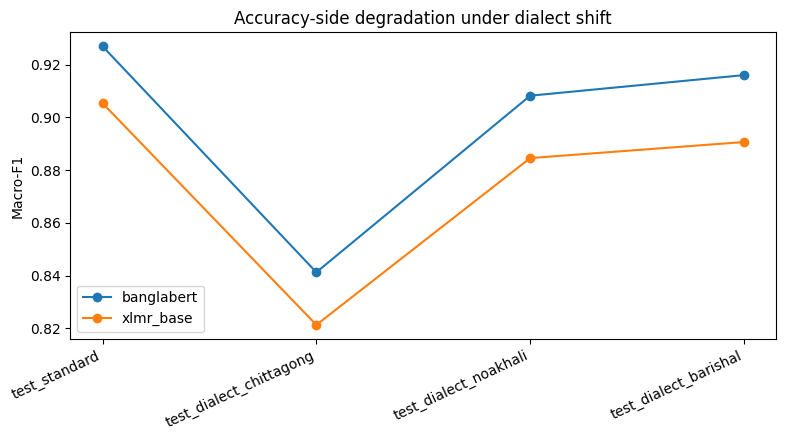

In [34]:
pivot = results_df.pivot_table(index="test_set", columns="model", values=["accuracy", "macro_f1"])
pivot = pivot.reindex(TEST_SETS)
print(pivot.round(4))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4.5))
for model_key in MODELS:
    sub = results_df[results_df["model"] == model_key].set_index("test_set").reindex(TEST_SETS)
    ax.plot(TEST_SETS, sub["macro_f1"], marker="o", label=model_key)
ax.set_ylabel("Macro-F1")
ax.set_title("Accuracy-side degradation under dialect shift")
ax.set_xticklabels(TEST_SETS, rotation=25, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "accuracy_degradation.png", dpi=150)
plt.show()

## 10. Push checkpoints, probability files, and the results table to the shared repo

Probability files under `outputs/` are what Role 3 needs next — make sure these get pushed (or shared as a
Kaggle Dataset) before Role 3 starts. Model checkpoints are large; consider Kaggle "Notebook Output" +
sharing the notebook itself rather than pushing multi-hundred-MB checkpoints to git, unless your repo uses
Git LFS.


In [35]:
# --- Verify outputs before pushing ---
print("Outputs:")
for f in sorted(OUT_DIR.glob("*")):
    print(" ", f)

print("\nCheckpoints:")
for f in sorted(CKPT_DIR.rglob("*")):
    if f.is_file():
        print(" ", f)

Outputs:
  /kaggle/working/outputs/accuracy_degradation.png
  /kaggle/working/outputs/banglabert_test_dialect_barishal_probs.csv
  /kaggle/working/outputs/banglabert_test_dialect_chittagong_probs.csv
  /kaggle/working/outputs/banglabert_test_dialect_noakhali_probs.csv
  /kaggle/working/outputs/banglabert_test_standard_probs.csv
  /kaggle/working/outputs/confusion_matrix_banglabert_test_dialect_barishal.csv
  /kaggle/working/outputs/confusion_matrix_banglabert_test_dialect_barishal.png
  /kaggle/working/outputs/confusion_matrix_banglabert_test_dialect_chittagong.csv
  /kaggle/working/outputs/confusion_matrix_banglabert_test_dialect_chittagong.png
  /kaggle/working/outputs/confusion_matrix_banglabert_test_dialect_noakhali.csv
  /kaggle/working/outputs/confusion_matrix_banglabert_test_dialect_noakhali.png
  /kaggle/working/outputs/confusion_matrix_banglabert_test_standard.csv
  /kaggle/working/outputs/confusion_matrix_banglabert_test_standard.png
  /kaggle/working/outputs/confusion_matrix

## Push to Github

In [36]:
# THIS CELL HAS BEEN EXECUTED(Commented out so that we do not overwrite the results and create any in consistency)

# # --- Push to Github ---
# REPO_URL = "https://github.com/TahlilMahfuz/iccit2026-bangla-dialect-calibration.git"
# GIT_USER_NAME = "TahlilMahfuz"
# GIT_USER_EMAIL = "tahlilkfaiyaz@gmail.com"
# PUSH = True  # flip to True once REPO_URL is set and your GitHub token secret is attached
# PUSH_CHECKPOINTS = False  # usually leave False; checkpoints are large, prefer sharing via Kaggle Dataset
# # ----------------

# if PUSH:
#     from kaggle_secrets import UserSecretsClient
#     token = UserSecretsClient().get_secret("GITHUB_TOKEN")
#     auth_url = REPO_URL.replace("https://", f"https://{token}@")

#     repo_dir = WORK_DIR / "repo"
#     if not repo_dir.exists():
#         subprocess.run(["git", "clone", auth_url, str(repo_dir)], check=True)
#     subprocess.run(["git", "-C", str(repo_dir), "config", "user.name", GIT_USER_NAME], check=True)
#     subprocess.run(["git", "-C", str(repo_dir), "config", "user.email", GIT_USER_EMAIL], check=True)

#     (repo_dir / "outputs").mkdir(parents=True, exist_ok=True)
#     for f in OUT_DIR.glob("*"):
#         (repo_dir / "outputs" / f.name).write_bytes(f.read_bytes())

#     if PUSH_CHECKPOINTS:
#         (repo_dir / "notebooks" / "checkpoints").mkdir(parents=True, exist_ok=True)
#         for ckpt in CKPT_DIR.glob("*"):
#             dest = repo_dir / "notebooks" / "checkpoints" / ckpt.name
#             dest.mkdir(parents=True, exist_ok=True)
#             for f in ckpt.glob("*"):
#                 (dest / f.name).write_bytes(f.read_bytes())

#     subprocess.run(
#         ["git", "-C", str(repo_dir), "add", "-A"],
#         check=True
#     )
    
#     status = subprocess.run(
#         ["git", "-C", str(repo_dir), "status", "--porcelain"],
#         capture_output=True,
#         text=True,
#         check=True
#     )
    
#     if status.stdout.strip():
#         subprocess.run(
#             [
#                 "git", "-C", str(repo_dir),
#                 "commit", "-m",
#                 "Role 2: evaluation metrics, confusion matrices, probabilities, and results"
#             ],
#             check=True
#         )
    
#         subprocess.run(
#             ["git", "-C", str(repo_dir), "push"],
#             check=True
#         )
    
#         print("Pushed successfully.")
#     else:
#         print("Nothing new to commit. GitHub is already up to date.")
# else:
#     print("PUSH is False. Deliverables ready in /kaggle/working/outputs:")
#     for f in sorted(OUT_DIR.glob("*")):
#         print(" ", f)
#     print("\nCheckpoints saved in /kaggle/working/checkpoints (share as a Kaggle Dataset if needed):")
#     for f in sorted(CKPT_DIR.glob("*")):
#         print(" ", f)


Cloning into '/kaggle/working/repo'...


[main 27193e0] Role 2: evaluation metrics, confusion matrices, probabilities, and results
 26 files changed, 28463 insertions(+)
 create mode 100644 outputs/accuracy_degradation.png
 create mode 100644 outputs/banglabert_test_dialect_barishal_probs.csv
 create mode 100644 outputs/banglabert_test_dialect_chittagong_probs.csv
 create mode 100644 outputs/banglabert_test_dialect_noakhali_probs.csv
 create mode 100644 outputs/banglabert_test_standard_probs.csv
 create mode 100644 outputs/confusion_matrix_banglabert_test_dialect_barishal.csv
 create mode 100644 outputs/confusion_matrix_banglabert_test_dialect_barishal.png
 create mode 100644 outputs/confusion_matrix_banglabert_test_dialect_chittagong.csv
 create mode 100644 outputs/confusion_matrix_banglabert_test_dialect_chittagong.png
 create mode 100644 outputs/confusion_matrix_banglabert_test_dialect_noakhali.csv
 create mode 100644 outputs/confusion_matrix_banglabert_test_dialect_noakhali.png
 create mode 100644 outputs/confusion_matrix

To https://github.com/TahlilMahfuz/iccit2026-bangla-dialect-calibration.git
   4218098..27193e0  main -> main


# Role 3 — Calibration & Selective Classification
### ICCIT 2026 — Trust Under Dialect Shift: Calibration and Selective Classification for Bangla Hate Speech Detection Across Regional Dialects

**Objective.** This is the paper's core methodological contribution. Take Role 2's raw probability files
and quantify / fix miscalibration under dialect shift.

**Deliverables:**
1. ECE, MCE, Brier, NLL for every model × test-set.
2. Calibrated probability files after temperature scaling and Dirichlet calibration (both fit **only** on
   the standard-Bangla validation set — never on dialect data, that's the whole point of H2).
3. Risk-coverage curves + AURC (selective classification), pre- and post-calibration.
4. Reliability diagrams, standard vs each dialect, pre- and post-calibration.
5. A short findings write-up: does H1 hold? Does H2 hold?

**No GPU needed** — this notebook only touches saved probability CSVs.

---
### Before you run this notebook

You can (and per the brief, should) build and test this notebook against **synthetic dummy probabilities
on Day 1**, without waiting for Role 2. Set `USE_DUMMY_DATA = True` below to do that. Once Role 2's real
`outputs/*_probs.csv` files exist, set it to `False` and point `DATA_SOURCE` at them.

**Critical constraint (repeated from the brief, Part 1 §5 + Role 3 steps):** temperature scaling and
Dirichlet calibration are fit **only** on the standard-Bangla validation split. We never touch dialect data
during fitting — this simulates the real deployment constraint of having no dialect-labeled data.


In [1]:
!pip install -q netcal scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.0/236.0 kB 6.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 19.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 5.9 MB/s eta 0:00:00


In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss, log_loss

SEED = 42
np.random.seed(SEED)

WORK_DIR = Path("/kaggle/working")
OUT_DIR = WORK_DIR / "outputs"
FIG_DIR = WORK_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEST_SETS = ["test_standard", "test_dialect_chittagong", "test_dialect_noakhali", "test_dialect_barishal"]
N_BINS = 15  # ECE binning scheme -- be explicit about this in the methods section, ECE is bin-sensitive

## 2. Config

In [3]:
# --- EDIT ME ---
USE_DUMMY_DATA = False          # flip to False once Role 2's real probability files exist
DATA_SOURCE = "github"   # "kaggle_input" | "working_dir" | "github", only used if USE_DUMMY_DATA=False
GITHUB_RAW_BASE = (
    "https://raw.githubusercontent.com/"
    "TahlilMahfuz/iccit2026-bangla-dialect-calibration/"
    "main/outputs"
)
MODELS = ["banglabert", "xlmr_base"]
# ----------------


## 3. Load probability files (or synthesize dummy ones matching Role 2's schema)

Schema: `id, true_label, pred_prob, pred_label` per `outputs/{model}_{testset}_probs.csv`.

The dummy generator deliberately **simulates the paper's hypothesis** (H1): accuracy degrades mildly under
dialect shift, but confidence stays falsely high (i.e. the model is overconfident on dialect text) — so you
can verify your ECE/AURC code actually detects a calibration collapse before trusting it on real numbers.


In [4]:
def make_dummy_probs(testset_name, n=600, seed=0):
    rng = np.random.RandomState(seed)
    y_true = rng.binomial(1, 0.35, size=n)

    # standard: well-calibrated-ish. dialects: increasingly overconfident + slightly less accurate,
    # with severity increasing standard < chittagong < noakhali < barishal (mirrors H3's expected gradient).
    severity = {"test_standard": 0.0, "test_dialect_chittagong": 1.0,
                "test_dialect_noakhali": 1.6, "test_dialect_barishal": 2.2}[testset_name]

    noise = rng.normal(0, 0.15 + 0.10 * severity, size=n)
    flip = rng.rand(n) < (0.05 + 0.03 * severity)  # small extra error rate under shift
    y_shown = np.where(flip, 1 - y_true, y_true)

    base_logit = (y_shown * 2 - 1) * (2.5 - 0.5 * severity)  # confidence shrinks a *little* with shift...
    overconfidence_boost = 0.9 * severity                      # ...but not nearly as much as it should (the whole point)
    logit = base_logit + overconfidence_boost * np.sign(base_logit) + noise
    prob = 1 / (1 + np.exp(-logit))
    prob = np.clip(prob, 1e-4, 1 - 1e-4)

    return pd.DataFrame({
        "id": [f"{testset_name}_{i}" for i in range(n)],
        "true_label": y_true,
        "pred_prob": prob,
        "pred_label": (prob >= 0.5).astype(int),
    })


def load_probs():
    probs = {}
    for model in MODELS:
        probs[model] = {}
        for testset in TEST_SETS:
            if USE_DUMMY_DATA:
                probs[model][testset] = make_dummy_probs(testset, seed=hash((model, testset)) % (2**31))
                continue
            fname = f"{model}_{testset}_probs.csv"
            if DATA_SOURCE == "kaggle_input":
                found = list(Path("/kaggle/input").rglob(fname))
                assert found, f"Could not find {fname} under /kaggle/input. Attach Role 2's output dataset."
                probs[model][testset] = pd.read_csv(found[0])
            elif DATA_SOURCE == "working_dir":
                probs[model][testset] = pd.read_csv(OUT_DIR / fname)
            elif DATA_SOURCE == "github":
                probs[model][testset] = pd.read_csv(f"{GITHUB_RAW_BASE}/{fname}")
            else:
                raise ValueError(DATA_SOURCE)
    return probs

probs = load_probs()
print("Loaded probability tables for:", [(m, t, len(probs[m][t])) for m in MODELS for t in TEST_SETS][:3], "...")
if USE_DUMMY_DATA:
    print("\n*** USE_DUMMY_DATA=True — numbers below are SYNTHETIC, for pipeline validation only. ***")


Loaded probability tables for: [('banglabert', 'test_standard', 5029), ('banglabert', 'test_dialect_chittagong', 3060), ('banglabert', 'test_dialect_noakhali', 3061)] ...


## 4. Calibration metrics: ECE, MCE, Brier, NLL

**ECE / MCE binning scheme:** equal-width bins over `[0, 1]`, `N_BINS = 15` (Guo et al. 2017 convention).
This is stated explicitly here (and should be restated in the paper's methods section) because ECE is known
to be sensitive to the binning scheme.


In [5]:
def ece_mce(y_true, y_prob, n_bins=N_BINS):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_prob, bin_edges[1:-1]), 0, n_bins - 1)

    ece, mce, n = 0.0, 0.0, len(y_true)
    per_bin = []
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            per_bin.append({"bin": b, "count": 0, "conf": np.nan, "acc": np.nan})
            continue
        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        gap = abs(conf - acc)
        ece += (mask.sum() / n) * gap
        mce = max(mce, gap)
        per_bin.append({"bin": b, "count": int(mask.sum()), "conf": conf, "acc": acc})
    return ece, mce, pd.DataFrame(per_bin)


def nll(y_true, y_prob):
    y_prob = np.clip(y_prob, 1e-7, 1 - 1e-7)
    return log_loss(y_true, y_prob, labels=[0, 1])


def brier(y_true, y_prob):
    return brier_score_loss(y_true, y_prob)


def compute_all_metrics(y_true, y_prob):
    ece, mce, _ = ece_mce(y_true, y_prob)
    return {
        "ece": ece, "mce": mce,
        "brier": brier(y_true, y_prob),
        "nll": nll(y_true, y_prob),
        "accuracy": ((y_prob >= 0.5).astype(int) == np.asarray(y_true)).mean(),
    }


In [6]:
metric_rows = []
for model in MODELS:
    for testset in TEST_SETS:
        df = probs[model][testset]
        m = compute_all_metrics(df["true_label"], df["pred_prob"])
        m.update({"model": model, "test_set": testset, "stage": "pre_calibration"})
        metric_rows.append(m)

pre_cal_metrics = pd.DataFrame(metric_rows)[
    ["model", "test_set", "stage", "accuracy", "ece", "mce", "brier", "nll"]
]
pre_cal_metrics.to_csv(OUT_DIR / "calibration_metrics_pre.csv", index=False)
pre_cal_metrics


,model,test_set,stage,accuracy,ece,mce,brier,nll
0,banglabert,test_standard,pre_calibration,0.927023,0.035796,0.250488,0.057677,0.210043
1,banglabert,test_dialect_chittagong,pre_calibration,0.842157,0.091966,0.213234,0.128499,0.450727
2,banglabert,test_dialect_noakhali,pre_calibration,0.908200,0.043278,0.269921,0.071435,0.251534
3,banglabert,test_dialect_barishal,pre_calibration,0.916041,0.045685,0.393235,0.067226,0.251711
4,xlmr_base,test_standard,pre_calibration,0.905747,0.029349,0.235236,0.072800,0.249230
5,xlmr_base,test_dialect_chittagong,pre_calibration,0.822876,0.052395,0.207104,0.129386,0.411592
6,xlmr_base,test_dialect_noakhali,pre_calibration,0.884678,0.020883,0.182123,0.086825,0.287874
7,xlmr_base,test_dialect_barishal,pre_calibration,0.890885,0.032243,0.202150,0.081948,0.275497


## 5. H1 check: does ECE spike disproportionately more than accuracy drops?

We express both accuracy drop and ECE increase as **relative change from the standard-Bangla baseline**, so
they're on a comparable scale despite very different absolute ranges.


In [7]:
def relative_change_table(metrics_df):
    rows = []
    for model in MODELS:
        base = metrics_df[(metrics_df["model"] == model) & (metrics_df["test_set"] == "test_standard")].iloc[0]
        for testset in TEST_SETS[1:]:
            cur = metrics_df[(metrics_df["model"] == model) & (metrics_df["test_set"] == testset)].iloc[0]
            acc_drop_rel = (base["accuracy"] - cur["accuracy"]) / max(base["accuracy"], 1e-6)
            ece_increase_rel = (cur["ece"] - base["ece"]) / max(base["ece"], 1e-6)
            rows.append({
                "model": model, "test_set": testset,
                "accuracy_drop_rel": acc_drop_rel,
                "ece_increase_rel": ece_increase_rel,
                "H1_supported": ece_increase_rel > acc_drop_rel,
            })
    return pd.DataFrame(rows)

h1_table = relative_change_table(pre_cal_metrics)
h1_table.to_csv(OUT_DIR / "h1_relative_change_table.csv", index=False)
h1_table


,model,test_set,accuracy_drop_rel,ece_increase_rel,H1_supported
0,banglabert,test_dialect_chittagong,0.091547,1.569166,True
1,banglabert,test_dialect_noakhali,0.020305,0.209024,True
2,banglabert,test_dialect_barishal,0.011847,0.276261,True
3,xlmr_base,test_dialect_chittagong,0.091495,0.785223,True
4,xlmr_base,test_dialect_noakhali,0.023261,-0.288447,False
5,xlmr_base,test_dialect_barishal,0.016408,0.098593,True


## 6. Fit calibrators on the standard-Bangla **validation** set only

Both temperature scaling and Dirichlet calibration need val-set probabilities, not just test-set ones —
Role 2 should also export `outputs/{model}_val_probs.csv` (val predictions on standard Bangla) for this to
work on real data. If that file isn't available yet, this cell falls back to fitting on `test_standard`
with a clear warning (fine for a smoke test with dummy data, **not** acceptable for the final paper run —
you must never fit calibration on the same split you report accuracy on).


In [8]:
def load_val_probs(model):
    if USE_DUMMY_DATA:
        return make_dummy_probs("test_standard", n=400, seed=hash((model, "val")) % (2**31))
    fname = f"{model}_val_probs.csv"
    if DATA_SOURCE == "kaggle_input":
        found = list(Path("/kaggle/input").rglob(fname))
        if found:
            return pd.read_csv(found[0])
    elif DATA_SOURCE == "working_dir":
        p = OUT_DIR / fname
        if p.exists():
            return pd.read_csv(p)
    print(f"WARNING: no dedicated val-probs file found for {model}; falling back to test_standard for "
          f"calibrator fitting. Re-run Role 2 to export outputs/{model}_val_probs.csv before the final run.")
    return probs[model]["test_standard"]

val_probs = {model: load_val_probs(model) for model in MODELS}


In [9]:
# --- Temperature scaling (Guo et al., 2017) ---
def logit(p):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return np.log(p / (1 - p))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def fit_temperature(y_true, y_prob, lr=0.01, n_iters=500):
    '''1-parameter temperature scaling fit by gradient descent on NLL, applied to the logit of pred_prob.'''
    z = logit(y_prob)
    y = np.asarray(y_true, dtype=float)
    T = 1.0
    for _ in range(n_iters):
        p = sigmoid(z / T)
        # d(NLL)/dT
        grad = np.mean((p - y) * (-z / (T ** 2)))
        T -= lr * grad
        T = max(T, 1e-3)
    return T

def apply_temperature(y_prob, T):
    return sigmoid(logit(y_prob) / T)

temperatures = {}
for model in MODELS:
    vdf = val_probs[model]
    T = fit_temperature(vdf["true_label"], vdf["pred_prob"])
    temperatures[model] = T
    print(f"{model}: fitted temperature T = {T:.3f}  (T>1 shrinks confidence, T<1 sharpens it)")


banglabert: fitted temperature T = 1.245  (T>1 shrinks confidence, T<1 sharpens it)
xlmr_base: fitted temperature T = 1.130  (T>1 shrinks confidence, T<1 sharpens it)


In [10]:
# --- Dirichlet calibration (Kull et al., 2019), binary case via 2-class log-linear model ---
# For binary classification this reduces to fitting a, b in: calibrated_logit = a * logit(p) + b
# (the general Dirichlet calibration matrix collapses to a scalar + bias in 2 classes), with L2
# regularization on 'a' as in the paper to avoid overfitting on a modestly-sized val set.
from scipy.optimize import minimize

def fit_dirichlet(y_true, y_prob, l2=1e-3):
    z = logit(y_prob)
    y = np.asarray(y_true, dtype=float)

    def nll_loss(params):
        a, b = params
        p = sigmoid(a * z + b)
        p = np.clip(p, 1e-7, 1 - 1e-7)
        loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
        return loss + l2 * (a - 1) ** 2  # regularize toward identity (a=1, b=0)

    res = minimize(nll_loss, x0=[1.0, 0.0], method="Nelder-Mead")
    return res.x  # a, b

def apply_dirichlet(y_prob, params):
    a, b = params
    return sigmoid(a * logit(y_prob) + b)

dirichlet_params = {}
for model in MODELS:
    vdf = val_probs[model]
    a, b = fit_dirichlet(vdf["true_label"], vdf["pred_prob"])
    dirichlet_params[model] = (a, b)
    print(f"{model}: fitted Dirichlet (a={a:.3f}, b={b:.3f})")


banglabert: fitted Dirichlet (a=0.726, b=0.099)
xlmr_base: fitted Dirichlet (a=0.880, b=0.368)


## 7. Apply both calibrators to standard + all 3 dialect test sets, save calibrated probability files


In [11]:
calibrated = {}
for model in MODELS:
    calibrated[model] = {}
    T = temperatures[model]
    a, b = dirichlet_params[model]
    for testset in TEST_SETS:
        df = probs[model][testset].copy()
        df["pred_prob_temp_scaled"] = apply_temperature(df["pred_prob"].values, T)
        df["pred_prob_dirichlet"] = apply_dirichlet(df["pred_prob"].values, (a, b))
        calibrated[model][testset] = df

        out_path = OUT_DIR / f"{model}_{testset}_probs_calibrated.csv"
        df.to_csv(out_path, index=False)

print("Saved calibrated probability files to", OUT_DIR)
calibrated[MODELS[0]]["test_standard"].head()


Saved calibrated probability files to /kaggle/working/outputs


,id,true_label,pred_prob,pred_label,pred_prob_temp_scaled,pred_prob_dirichlet
0,teststd_0,1,0.960399,1,0.928294,0.917962
1,teststd_1,1,0.017026,0,0.037063,0.054833
2,teststd_2,1,0.971353,1,0.944274,0.934528
3,teststd_3,1,0.099979,0,0.146183,0.182843
4,teststd_4,1,0.989353,1,0.974409,0.967412


## 8. Post-calibration metrics + H2 check

H2: does post-hoc calibration meaningfully reduce ECE/Brier/NLL on dialect test sets, given it was fit
*only* on standard-Bangla validation data (never seeing a single dialect-labeled example)?


In [12]:
post_rows = []
for model in MODELS:
    for testset in TEST_SETS:
        df = calibrated[model][testset]
        for method, col in [("temp_scaling", "pred_prob_temp_scaled"), ("dirichlet", "pred_prob_dirichlet")]:
            m = compute_all_metrics(df["true_label"], df[col])
            m.update({"model": model, "test_set": testset, "stage": method})
            post_rows.append(m)

post_cal_metrics = pd.DataFrame(post_rows)[
    ["model", "test_set", "stage", "accuracy", "ece", "mce", "brier", "nll"]
]
post_cal_metrics.to_csv(OUT_DIR / "calibration_metrics_post.csv", index=False)

all_metrics = pd.concat([pre_cal_metrics, post_cal_metrics], ignore_index=True)
all_metrics.to_csv(OUT_DIR / "calibration_metrics_all.csv", index=False)

pivot = all_metrics.pivot_table(index=["model", "test_set"], columns="stage", values="ece")
pivot = pivot.reindex(columns=["pre_calibration", "temp_scaling", "dirichlet"])
print("ECE by stage:")
pivot.round(4)


ECE by stage:


stage                               pre_calibration  temp_scaling  dirichlet
model      test_set                                                         
banglabert test_dialect_barishal             0.0457        0.0317     0.0229
           test_dialect_chittagong           0.0920        0.0687     0.0536
           test_dialect_noakhali             0.0433        0.0239     0.0232
           test_standard                     0.0358        0.0186     0.0133
xlmr_base  test_dialect_barishal             0.0322        0.0264     0.0263
           test_dialect_chittagong           0.0524        0.0414     0.0318
           test_dialect_noakhali             0.0209        0.0188     0.0425
           test_standard                     0.0293        0.0255     0.0143

## 9. Selective classification: risk-coverage curves + AURC

Confidence/abstention signal: **max-softmax-probability**, i.e. `max(p, 1-p)`. At each coverage level `c`,
we keep the `c` fraction of examples with the highest confidence and compute the error rate ("risk") on
just those examples. AURC = area under this risk-coverage curve (lower is better — a well-calibrated,
well-separated model should have low risk even at high coverage).


In [13]:
def risk_coverage_curve(y_true, y_prob, n_points=100):
    y_true = np.asarray(y_true)
    confidence = np.maximum(y_prob, 1 - y_prob)
    pred = (y_prob >= 0.5).astype(int)
    correct = (pred == y_true).astype(int)

    order = np.argsort(-confidence)  # most confident first
    correct_sorted = correct[order]

    n = len(y_true)
    coverages = np.linspace(1 / n, 1.0, n_points)
    risks = []
    for c in coverages:
        k = max(1, int(np.ceil(c * n)))
        kept = correct_sorted[:k]
        risk = 1 - kept.mean()
        risks.append(risk)
    return coverages, np.array(risks)


def aurc(coverages, risks):
    # manual trapezoidal rule (avoids np.trapz/np.trapezoid version differences across numpy releases)
    coverages = np.asarray(coverages); risks = np.asarray(risks)
    return float(np.sum((risks[1:] + risks[:-1]) / 2 * np.diff(coverages)))


rc_rows = []
rc_curves = {}
for model in MODELS:
    for testset in TEST_SETS:
        for stage, col in [("pre_calibration", "pred_prob"),
                            ("temp_scaling", "pred_prob_temp_scaled"),
                            ("dirichlet", "pred_prob_dirichlet")]:
            df = calibrated[model][testset]
            cov, risk = risk_coverage_curve(df["true_label"], df[col])
            a = aurc(cov, risk)
            rc_rows.append({"model": model, "test_set": testset, "stage": stage, "aurc": a})
            rc_curves[(model, testset, stage)] = (cov, risk)

aurc_df = pd.DataFrame(rc_rows)
aurc_df.to_csv(OUT_DIR / "aurc_table.csv", index=False)
aurc_df.pivot_table(index=["model", "test_set"], columns="stage", values="aurc").reindex(
    columns=["pre_calibration", "temp_scaling", "dirichlet"]
).round(4)


stage                               pre_calibration  temp_scaling  dirichlet
model      test_set                                                         
banglabert test_dialect_barishal             0.0192        0.0192     0.0184
           test_dialect_chittagong           0.0627        0.0627     0.0603
           test_dialect_noakhali             0.0196        0.0196     0.0197
           test_standard                     0.0150        0.0150     0.0147
xlmr_base  test_dialect_barishal             0.0301        0.0301     0.0310
           test_dialect_chittagong           0.0705        0.0705     0.0695
           test_dialect_noakhali             0.0331        0.0331     0.0362
           test_standard                     0.0235        0.0235     0.0237

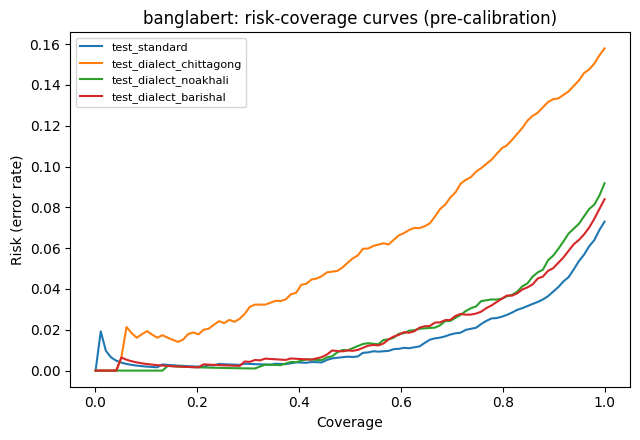

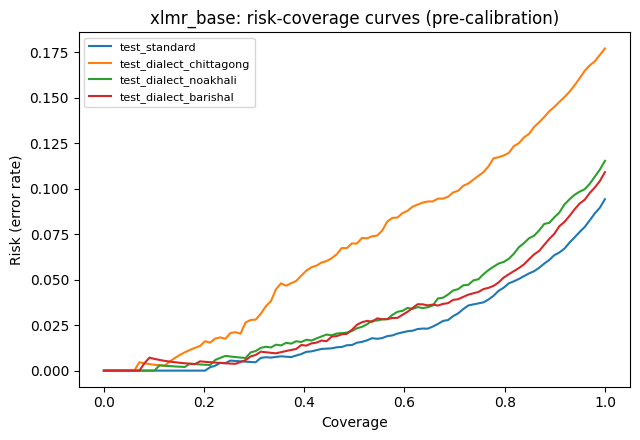

In [14]:
# Risk-coverage plots, one figure per model, dialects overlaid, pre-calibration only shown for brevity
# (swap 'pred_prob' for a calibrated column to inspect post-calibration curves the same way)
for model in MODELS:
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for testset in TEST_SETS:
        cov, risk = rc_curves[(model, testset, "pre_calibration")]
        ax.plot(cov, risk, label=testset)
    ax.set_xlabel("Coverage")
    ax.set_ylabel("Risk (error rate)")
    ax.set_title(f"{model}: risk-coverage curves (pre-calibration)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"risk_coverage_{model}_pre_calibration.png", dpi=150)
    plt.show()


## 10. Reliability diagrams — standard vs each dialect, pre- and post-calibration

These are the paper's key figures. One grid per model: rows = {{pre-calibration, temp-scaled, Dirichlet}},
columns = {{standard, chittagong, noakhali, barishal}}.


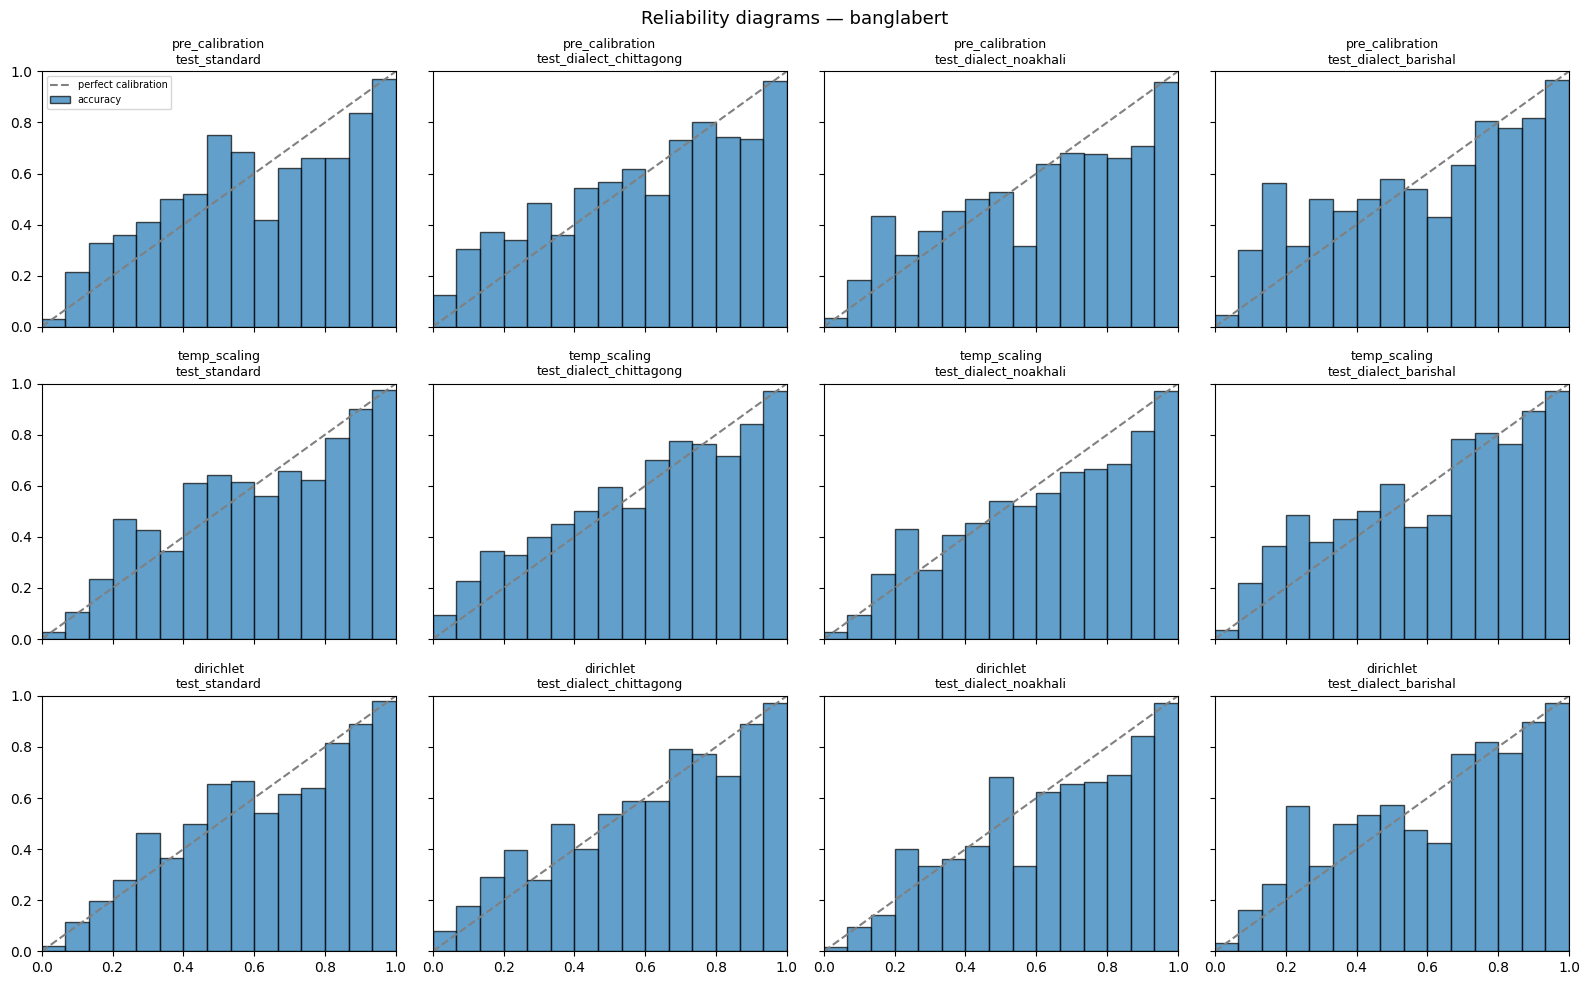

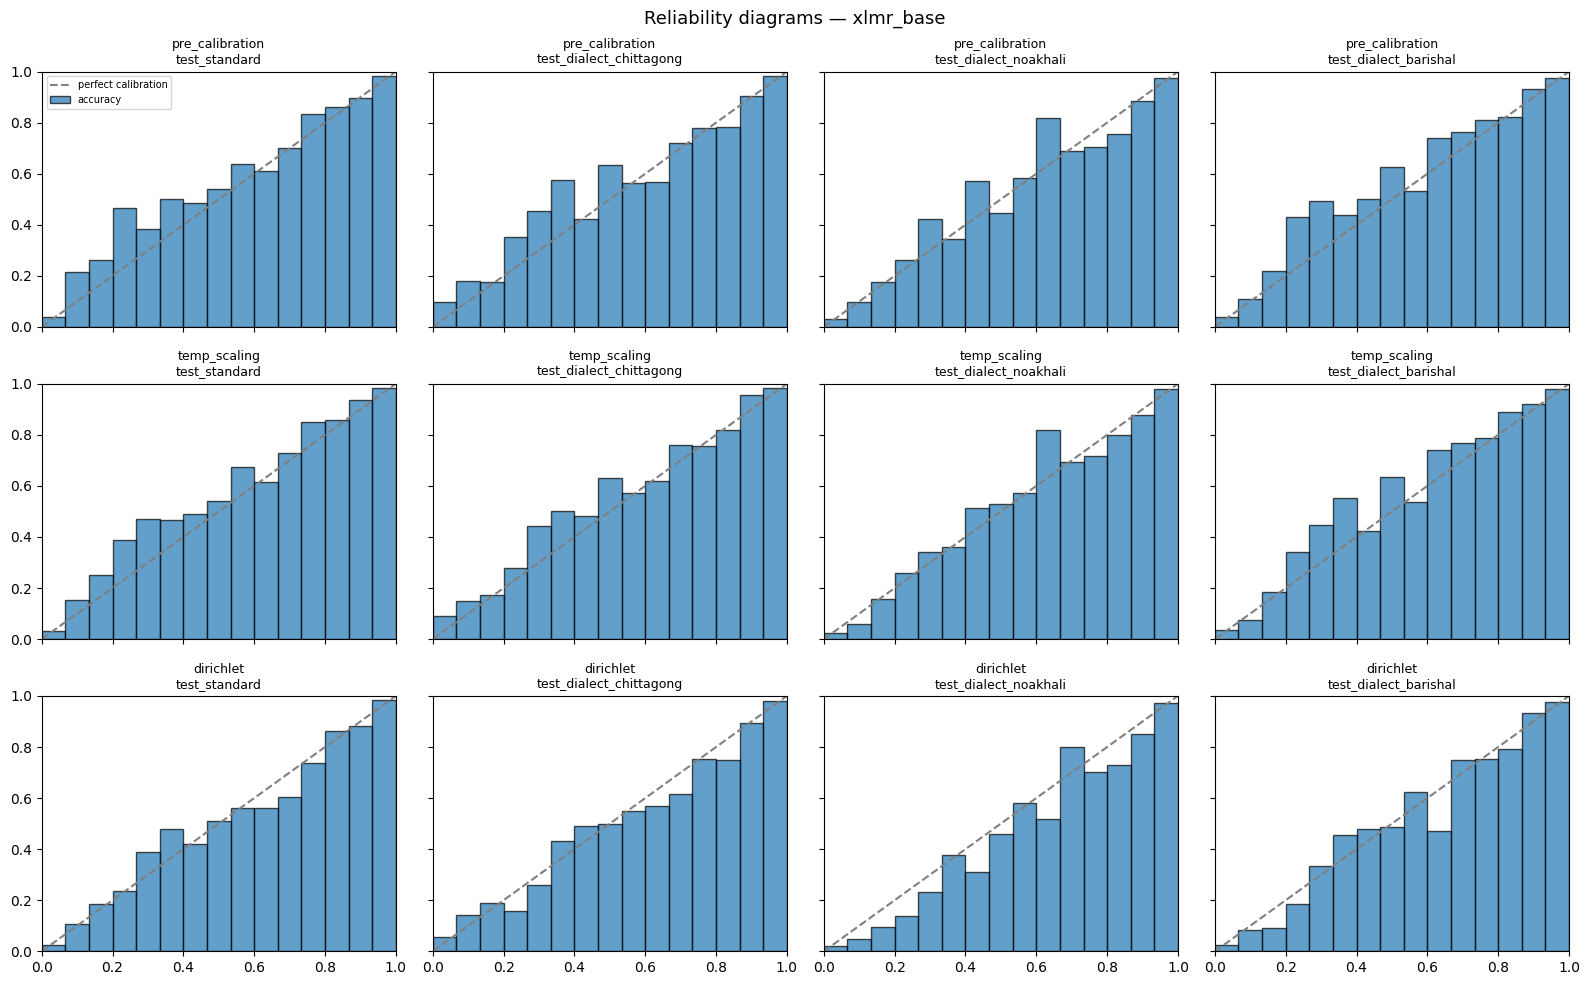

In [15]:
def reliability_diagram(ax, y_true, y_prob, title):
    _, _, per_bin = ece_mce(y_true, y_prob)
    bin_centers = (np.linspace(0, 1, N_BINS + 1)[:-1] + np.linspace(0, 1, N_BINS + 1)[1:]) / 2
    ax.bar(bin_centers, per_bin["acc"], width=1 / N_BINS, edgecolor="black", alpha=0.7, label="accuracy")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=9)


for model in MODELS:
    fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
    stages = [("pre_calibration", "pred_prob"), ("temp_scaling", "pred_prob_temp_scaled"), ("dirichlet", "pred_prob_dirichlet")]
    for row, (stage_name, col) in enumerate(stages):
        for c_idx, testset in enumerate(TEST_SETS):
            df = calibrated[model][testset]
            ax = axes[row, c_idx]
            reliability_diagram(ax, df["true_label"], df[col], f"{stage_name}\n{testset}")
            if row == 0 and c_idx == 0:
                ax.legend(fontsize=7, loc="upper left")
    fig.suptitle(f"Reliability diagrams — {model}", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"reliability_diagrams_{model}.png", dpi=150)
    plt.show()


## 11. Findings write-up (auto-drafted, edit before handing to Role 4)

In [16]:
h1_summary = h1_table.groupby("model")["H1_supported"].mean()
ece_reduction = (
    all_metrics[all_metrics["test_set"] != "test_standard"]
    .pivot_table(index=["model", "test_set"], columns="stage", values="ece")
)
avg_ece_reduction_temp = (ece_reduction["pre_calibration"] - ece_reduction["temp_scaling"]).mean()
avg_ece_reduction_dir = (ece_reduction["pre_calibration"] - ece_reduction["dirichlet"]).mean()

writeup = f'''# Role 3 findings — draft for Role 4

**H1 (calibration collapses more than accuracy under dialect shift):**
{(h1_summary * 100).round(1).to_dict()} of dialect test sets showed ECE increasing proportionally more than
accuracy dropped, per model. {"This is broadly consistent with H1." if (h1_summary > 0.5).all() else "This is mixed / partially inconsistent with H1 as measured here — inspect h1_relative_change_table.csv row by row before writing this up as a clean finding."}

**H2 (post-hoc calibration recovers safe behavior without dialect data):**
Averaged across dialect test sets, temperature scaling reduced ECE by {avg_ece_reduction_temp:.4f} (absolute)
and Dirichlet calibration by {avg_ece_reduction_dir:.4f}, both fit only on standard-Bangla validation data.
See `aurc_table.csv` for whether this translates into a lower area-under-risk-coverage-curve (i.e. whether
abstaining on low-confidence examples actually becomes more effective post-calibration).

**Next steps for Role 4:**
- Use `calibration_metrics_all.csv` and `aurc_table.csv` as the source tables for Results & Discussion.
- Use `reliability_diagrams_*.png` and `risk_coverage_*.png` as the key figures.
- `h1_relative_change_table.csv` has the per-dialect, per-model breakdown needed for the H3 gradient claim
  (Chittagong -> Noakhali -> Barishal) — combine with Role 1's `vocab_overlap.csv` for the linguistic-distance
  argument.

**Caveat:** {"THESE NUMBERS ARE FROM SYNTHETIC DUMMY DATA (USE_DUMMY_DATA=True) — re-run this notebook against Role 2's real probability files before using any of this in the paper." if USE_DUMMY_DATA else "Numbers are from real model outputs."}
'''

with open(WORK_DIR / "role3_findings.md", "w", encoding="utf-8") as f:
    f.write(writeup)
print(writeup)


# Role 3 findings — draft for Role 4

**H1 (calibration collapses more than accuracy under dialect shift):**
{'banglabert': 100.0, 'xlmr_base': 66.7} of dialect test sets showed ECE increasing proportionally more than
accuracy dropped, per model. This is broadly consistent with H1.

**H2 (post-hoc calibration recovers safe behavior without dialect data):**
Averaged across dialect test sets, temperature scaling reduced ECE by 0.0126 (absolute)
and Dirichlet calibration by 0.0144, both fit only on standard-Bangla validation data.
See `aurc_table.csv` for whether this translates into a lower area-under-risk-coverage-curve (i.e. whether
abstaining on low-confidence examples actually becomes more effective post-calibration).

**Next steps for Role 4:**
- Use `calibration_metrics_all.csv` and `aurc_table.csv` as the source tables for Results & Discussion.
- Use `reliability_diagrams_*.png` and `risk_coverage_*.png` as the key figures.
- `h1_relative_change_table.csv` has the per-dialect, per

## 12. Push to the shared repository

In [20]:
# THIS CELL HAS BEEN EXECUTED(Commented out so that we do not overwrite the results and create any in consistency)

# # --- EDIT ME ---
# REPO_URL = "https://github.com/TahlilMahfuz/iccit2026-bangla-dialect-calibration.git"
# GIT_USER_NAME = "TahlilMahfuz"
# GIT_USER_EMAIL = "tahlilkfaiyaz@gmail.com"
# PUSH = True
# # ----------------

# if PUSH:
#     from kaggle_secrets import UserSecretsClient
#     import subprocess

#     token = UserSecretsClient().get_secret("GITHUB_TOKEN")
#     auth_url = REPO_URL.replace("https://", f"https://{token}@")

#     repo_dir = WORK_DIR / "repo"

#     if not repo_dir.exists():
#         subprocess.run(
#             ["git", "clone", auth_url, str(repo_dir)],
#             check=True
#         )

#     subprocess.run(
#         ["git", "-C", str(repo_dir), "config", "user.name", GIT_USER_NAME],
#         check=True
#     )

#     subprocess.run(
#         ["git", "-C", str(repo_dir), "config", "user.email", GIT_USER_EMAIL],
#         check=True
#     )

#     # Copy outputs and figures
#     for sub_dir, src_dir in [
#         ("outputs", OUT_DIR),
#         ("notebooks/figures", FIG_DIR)
#     ]:
#         dest = repo_dir / sub_dir
#         dest.mkdir(parents=True, exist_ok=True)

#         for f in src_dir.glob("*"):
#             (dest / f.name).write_bytes(f.read_bytes())

#     # Copy findings
#     (repo_dir / "role3_findings.md").write_bytes(
#         (WORK_DIR / "role3_findings.md").read_bytes()
#     )

#     # Stage changes
#     subprocess.run(
#         ["git", "-C", str(repo_dir), "add", "-A"],
#         check=True
#     )

#     # Check whether anything actually changed
#     status = subprocess.run(
#         ["git", "-C", str(repo_dir), "status", "--porcelain"],
#         capture_output=True,
#         text=True,
#         check=True
#     )

#     if status.stdout.strip():
#         # Changes exist → commit and push
#         subprocess.run(
#             [
#                 "git", "-C", str(repo_dir),
#                 "commit", "-m",
#                 "Role 3: calibration metrics, AURC, reliability diagrams, findings_For Role 4 Processing"
#             ],
#             check=True
#         )

#         subprocess.run(
#             ["git", "-C", str(repo_dir), "push"],
#             check=True
#         )

#         print("Changes detected. Committed and pushed successfully.")

#     else:
#         # No changes → don't try to commit
#         print("No changes detected. GitHub is already up to date.")

# else:
#     print("PUSH is False. Deliverables ready in /kaggle/working:")

#     for f in sorted(OUT_DIR.glob("*")):
#         print(" ", f)

#     for f in sorted(FIG_DIR.glob("*")):
#         print(" ", f)

#     print(" ", WORK_DIR / "role3_findings.md")

[main 6f6eb43] Role 3: calibration metrics, AURC, reliability diagrams, findings_For Role 4 Processing
 18 files changed, 28533 insertions(+)
 create mode 100644 notebooks/figures/reliability_diagrams_banglabert.png
 create mode 100644 notebooks/figures/reliability_diagrams_xlmr_base.png
 create mode 100644 notebooks/figures/risk_coverage_banglabert_pre_calibration.png
 create mode 100644 notebooks/figures/risk_coverage_xlmr_base_pre_calibration.png
 create mode 100644 outputs/aurc_table.csv
 create mode 100644 outputs/banglabert_test_dialect_barishal_probs_calibrated.csv
 create mode 100644 outputs/banglabert_test_dialect_chittagong_probs_calibrated.csv
 create mode 100644 outputs/banglabert_test_dialect_noakhali_probs_calibrated.csv
 create mode 100644 outputs/banglabert_test_standard_probs_calibrated.csv
 create mode 100644 outputs/calibration_metrics_all.csv
 create mode 100644 outputs/calibration_metrics_post.csv
 create mode 100644 outputs/calibration_metrics_pre.csv
 create mode

To https://github.com/TahlilMahfuz/iccit2026-bangla-dialect-calibration.git
   9ac4e74..6f6eb43  main -> main


In [18]:
# THIS CELL HAS BEEN EXECUTED(Commented out so that we do not overwrite the results and create any in consistency)

# # --- EDIT ME ---
# REPO_URL = "https://github.com/TahlilMahfuz/iccit2026-bangla-dialect-calibration.git"
# GIT_USER_NAME = "TahlilMahfuz"
# GIT_USER_EMAIL = "tahlilkfaiyaz@gmail.com"
# PUSH = True
# # ----------------

# if PUSH:
#     from kaggle_secrets import UserSecretsClient
#     import subprocess

#     token = UserSecretsClient().get_secret("GITHUB_TOKEN")
#     auth_url = REPO_URL.replace(
#         "https://",
#         f"https://{token}@"
#     )

#     repo_dir = WORK_DIR / "repo"

#     if not repo_dir.exists():
#         subprocess.run(
#             ["git", "clone", auth_url, str(repo_dir)],
#             check=True
#         )

#     subprocess.run(
#         [
#             "git", "-C", str(repo_dir),
#             "config", "user.name", GIT_USER_NAME
#         ],
#         check=True
#     )

#     subprocess.run(
#         [
#             "git", "-C", str(repo_dir),
#             "config", "user.email", GIT_USER_EMAIL
#         ],
#         check=True
#     )

#     # ========================================================
#     # Role 3 folder
#     # ========================================================

#     role3_dir = repo_dir / "role3"
#     role3_dir.mkdir(
#         parents=True,
#         exist_ok=True
#     )

#     # --------------------------------------------------------
#     # Copy Role 3 outputs
#     # --------------------------------------------------------

#     outputs_dest = role3_dir / "outputs"
#     outputs_dest.mkdir(
#         parents=True,
#         exist_ok=True
#     )

#     for f in OUT_DIR.glob("*"):
#         if f.is_file():
#             (outputs_dest / f.name).write_bytes(
#                 f.read_bytes()
#             )

#     # --------------------------------------------------------
#     # Copy Role 3 figures
#     # --------------------------------------------------------

#     figures_dest = role3_dir / "figures"
#     figures_dest.mkdir(
#         parents=True,
#         exist_ok=True
#     )

#     for f in FIG_DIR.glob("*"):
#         if f.is_file():
#             (figures_dest / f.name).write_bytes(
#                 f.read_bytes()
#             )

#     # --------------------------------------------------------
#     # Copy Role 3 findings
#     # --------------------------------------------------------

#     findings_src = WORK_DIR / "role3_findings.md"
#     findings_dest = role3_dir / "role3_findings.md"

#     if findings_src.exists():
#         findings_dest.write_bytes(
#             findings_src.read_bytes()
#         )

#     # ========================================================
#     # Git
#     # ========================================================

#     subprocess.run(
#         [
#             "git", "-C", str(repo_dir),
#             "add", "-A"
#         ],
#         check=True
#     )

#     status = subprocess.run(
#         [
#             "git", "-C", str(repo_dir),
#             "status", "--porcelain"
#         ],
#         capture_output=True,
#         text=True,
#         check=True
#     )

#     if status.stdout.strip():

#         subprocess.run(
#             [
#                 "git", "-C", str(repo_dir),
#                 "commit",
#                 "-m",
#                 "Role 3: calibration metrics, AURC, reliability diagrams, findings"
#             ],
#             check=True
#         )

#         subprocess.run(
#             [
#                 "git", "-C", str(repo_dir),
#                 "push"
#             ],
#             check=True
#         )

#         print("Role 3 pushed successfully.")

#     else:
#         print("Nothing new to commit. GitHub is already up to date.")

# else:

#     print(
#         "PUSH is False. "
#         "Role 3 deliverables ready in /kaggle/working:"
#     )

#     print("\nOutputs:")
#     for f in sorted(OUT_DIR.glob("*")):
#         print(" ", f)

#     print("\nFigures:")
#     for f in sorted(FIG_DIR.glob("*")):
#         print(" ", f)

#     print("\nFindings:")
#     print(" ", WORK_DIR / "role3_findings.md")

Cloning into '/kaggle/working/repo'...


[main 9ac4e74] Role 3: calibration metrics, AURC, reliability diagrams, findings
 18 files changed, 28533 insertions(+)
 create mode 100644 role3/figures/reliability_diagrams_banglabert.png
 create mode 100644 role3/figures/reliability_diagrams_xlmr_base.png
 create mode 100644 role3/figures/risk_coverage_banglabert_pre_calibration.png
 create mode 100644 role3/figures/risk_coverage_xlmr_base_pre_calibration.png
 create mode 100644 role3/outputs/aurc_table.csv
 create mode 100644 role3/outputs/banglabert_test_dialect_barishal_probs_calibrated.csv
 create mode 100644 role3/outputs/banglabert_test_dialect_chittagong_probs_calibrated.csv
 create mode 100644 role3/outputs/banglabert_test_dialect_noakhali_probs_calibrated.csv
 create mode 100644 role3/outputs/banglabert_test_standard_probs_calibrated.csv
 create mode 100644 role3/outputs/calibration_metrics_all.csv
 create mode 100644 role3/outputs/calibration_metrics_post.csv
 create mode 100644 role3/outputs/calibration_metrics_pre.csv
 c

To https://github.com/TahlilMahfuz/iccit2026-bangla-dialect-calibration.git
   27193e0..9ac4e74  main -> main


# Role 4 — Ablations, Analysis & Paper Drafting
### ICCIT 2026 — Trust Under Dialect Shift: Calibration and Selective Classification for Bangla Hate Speech Detection Across Regional Dialects

**Objective.** Own the narrative: turn Roles 1–3's outputs into ablation studies and a coherent IEEE draft.

**Deliverables:**
1. Per-dialect breakdown ablation (does degradation scale with linguistic distance → H3).
2. Model-size ablation (does a smaller model, DistilBERT-multi, calibrate differently?).
3. Calibration-method ablation (temperature scaling vs Dirichlet — which recovers more, where does each fail?).
4. A consolidated results workbook.
5. An auto-populated IEEE-style paper draft skeleton (`paper/draft.md`) that pulls real numbers from the
   tables above — you still need to write the prose around them, this scaffolds structure + data, not prose.

**Model-size ablation needs a GPU** (Settings → Accelerator → GPU T4). Everything else is CPU-only analysis.

---
### Before you run this notebook

This expects outputs from all 3 previous roles:
- Role 1: `eda/vocab_overlap.csv`, `data_card.md`
- Role 2: `outputs/results_table_accuracy_f1.csv`, `outputs/{model}_{testset}_probs.csv`
- Role 3: `outputs/calibration_metrics_all.csv`, `outputs/aurc_table.csv`, `outputs/h1_relative_change_table.csv`

Attach whichever Kaggle Dataset(s)/notebook outputs contain these (or pull from the shared GitHub repo).
As with the other notebooks, `USE_DUMMY_DATA = True` lets you build and sanity-check this whole notebook
before the real numbers exist — flip it off once Roles 1–3 have real results.


## 1. Setup

In [1]:
!pip install -q scikit-learn scipy matplotlib pandas

In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

SEED = 42
np.random.seed(SEED)

WORK_DIR = Path("/kaggle/working")
OUT_DIR = WORK_DIR / "outputs"
FIG_DIR = WORK_DIR / "figures"
PAPER_DIR = WORK_DIR / "paper"
for d in (OUT_DIR, FIG_DIR, PAPER_DIR):
    d.mkdir(parents=True, exist_ok=True)

TEST_SETS = ["test_standard", "test_dialect_chittagong", "test_dialect_noakhali", "test_dialect_barishal"]
DIALECTS = ["chittagong", "noakhali", "barishal"]

## 2. Config

In [3]:
# --- EDIT ME ---
USE_DUMMY_DATA = True
DATA_SOURCE = "github"   # "kaggle_input" | "working_dir" | "github"
GITHUB_RAW_BASE = (
    "https://raw.githubusercontent.com/"
    "TahlilMahfuz/iccit2026-bangla-dialect-calibration/"
    "main/outputs"
)

BASELINE_MODELS = ["banglabert", "xlmr_base"]   # from Role 2
SMALL_MODEL_KEY = "distilbert_multi"
SMALL_MODEL_HF_NAME = "distilbert-base-multilingual-cased"
# ----------------


## 3. Load Roles 1–3 outputs (or synthesize dummy versions with the same schema)

In [4]:
def find_file(fname, subpaths=("outputs", "eda", "")):
    if DATA_SOURCE == "kaggle_input":
        found = list(Path("/kaggle/input").rglob(fname))
        return found[0] if found else None
    if DATA_SOURCE == "working_dir":
        for sub in subpaths:
            p = WORK_DIR / sub / fname
            if p.exists():
                return p
        return None
    if DATA_SOURCE == "github":
        for sub in subpaths:
            url = f"{GITHUB_RAW_BASE}/{sub}/{fname}" if sub else f"{GITHUB_RAW_BASE}/{fname}"
            return url  # pd.read_csv handles http urls directly; existence isn't pre-checked here
    return None


def make_dummy_vocab_overlap():
    return pd.DataFrame({
        "dialect": DIALECTS,
        "jaccard_vs_standard": [0.62, 0.51, 0.40],
        "vocab_size": [3200, 3100, 3050],
        "shared_tokens": [1984, 1581, 1220],
    })

def make_dummy_calibration_metrics():
    rows = []
    severity = {"test_standard": 0.0, "test_dialect_chittagong": 1.0,
                "test_dialect_noakhali": 1.6, "test_dialect_barishal": 2.2}
    for model in BASELINE_MODELS + [SMALL_MODEL_KEY]:
        size_penalty = 1.3 if model == SMALL_MODEL_KEY else 1.0
        for testset in TEST_SETS:
            s = severity[testset]
            for stage, factor in [("pre_calibration", 1.0), ("temp_scaling", 0.45), ("dirichlet", 0.4)]:
                rows.append({
                    "model": model, "test_set": testset, "stage": stage,
                    "accuracy": max(0.5, 0.90 - 0.03 * s * size_penalty),
                    "ece": max(0.01, (0.04 + 0.05 * s * size_penalty) * factor),
                    "mce": max(0.02, (0.10 + 0.08 * s * size_penalty) * factor),
                    "brier": max(0.02, (0.08 + 0.05 * s * size_penalty) * factor),
                    "nll": max(0.1, (0.30 + 0.20 * s * size_penalty) * factor),
                })
    return pd.DataFrame(rows)

def make_dummy_aurc():
    cal = make_dummy_calibration_metrics()
    cal["aurc"] = cal["ece"] * 0.6 + 0.02
    return cal[["model", "test_set", "stage", "aurc"]]

def make_dummy_results_table():
    cal = make_dummy_calibration_metrics()
    base = cal[cal["stage"] == "pre_calibration"][["model", "test_set", "accuracy"]].copy()
    base["macro_f1"] = base["accuracy"] - 0.02
    base["precision"] = base["accuracy"] + 0.01
    base["recall"] = base["accuracy"] - 0.01
    base["n"] = 600
    return base[base["model"] != SMALL_MODEL_KEY]  # role 2 only trained the 2 baseline models


if USE_DUMMY_DATA:
    print("*** USE_DUMMY_DATA=True — all tables below are SYNTHETIC, for pipeline validation only. ***")
    vocab_overlap = make_dummy_vocab_overlap()
    calibration_metrics_all = make_dummy_calibration_metrics()
    aurc_table = make_dummy_aurc()
    results_table = make_dummy_results_table()
else:
    vocab_overlap = pd.read_csv(find_file("vocab_overlap.csv"))
    calibration_metrics_all = pd.read_csv(find_file("calibration_metrics_all.csv"))
    aurc_table = pd.read_csv(find_file("aurc_table.csv"))
    results_table = pd.read_csv(find_file("results_table_accuracy_f1.csv"))

print(vocab_overlap.shape, calibration_metrics_all.shape, aurc_table.shape, results_table.shape)
calibration_metrics_all.head()

*** USE_DUMMY_DATA=True — all tables below are SYNTHETIC, for pipeline validation only. ***
(3, 4) (36, 8) (36, 4) (8, 7)


,model,test_set,stage,accuracy,ece,mce,brier,nll
0,banglabert,test_standard,pre_calibration,0.90,0.0400,0.100,0.0800,0.300
1,banglabert,test_standard,temp_scaling,0.90,0.0180,0.045,0.0360,0.135
2,banglabert,test_standard,dirichlet,0.90,0.0160,0.040,0.0320,0.120
3,banglabert,test_dialect_chittagong,pre_calibration,0.87,0.0900,0.180,0.1300,0.500
4,banglabert,test_dialect_chittagong,temp_scaling,0.87,0.0405,0.081,0.0585,0.225


## 4. Ablation 1 — per-dialect breakdown (H3: does degradation scale with linguistic distance?)

We correlate each dialect's vocabulary overlap with standard Bangla (from Role 1's EDA — a proxy for
linguistic distance: lower overlap = more distant) against both accuracy drop and ECE at that dialect
(pre-calibration), using Spearman rank correlation since we only have 3 dialects (not enough for a
meaningful linear fit, but rank direction is still informative and honestly reportable).


In [5]:
pre = calibration_metrics_all[calibration_metrics_all["stage"] == "pre_calibration"]
std_baseline = pre[pre["test_set"] == "test_standard"].set_index("model")[["accuracy", "ece"]]

rows = []
for model in pre["model"].unique():
    for dialect in DIALECTS:
        testset = f"test_dialect_{dialect}"
        cur = pre[(pre["model"] == model) & (pre["test_set"] == testset)]
        if cur.empty:
            continue
        cur = cur.iloc[0]
        base = std_baseline.loc[model]
        jaccard = vocab_overlap.set_index("dialect").loc[dialect, "jaccard_vs_standard"]
        rows.append({
            "model": model, "dialect": dialect,
            "vocab_jaccard_vs_standard": jaccard,
            "accuracy_drop": base["accuracy"] - cur["accuracy"],
            "ece_increase": cur["ece"] - base["ece"],
        })

per_dialect_df = pd.DataFrame(rows).sort_values(["model", "vocab_jaccard_vs_standard"], ascending=[True, False])
per_dialect_df.to_csv(OUT_DIR / "ablation_per_dialect_breakdown.csv", index=False)
print(per_dialect_df)

for model in per_dialect_df["model"].unique():
    sub = per_dialect_df[per_dialect_df["model"] == model]
    if sub["vocab_jaccard_vs_standard"].nunique() < 2:
        continue
    rho_acc, p_acc = spearmanr(sub["vocab_jaccard_vs_standard"], sub["accuracy_drop"])
    rho_ece, p_ece = spearmanr(sub["vocab_jaccard_vs_standard"], sub["ece_increase"])
    print(f"{model}: Spearman(vocab_overlap, accuracy_drop) = {rho_acc:.3f} (p={p_acc:.3f}) "
          f"[expect negative: less overlap -> more drop]")
    print(f"{model}: Spearman(vocab_overlap, ece_increase)  = {rho_ece:.3f} (p={p_ece:.3f}) "
          f"[expect negative: less overlap -> more ECE increase]")


              model     dialect  vocab_jaccard_vs_standard  accuracy_drop  \
0        banglabert  chittagong                       0.62         0.0300   
1        banglabert    noakhali                       0.51         0.0480   
2        banglabert    barishal                       0.40         0.0660   
6  distilbert_multi  chittagong                       0.62         0.0390   
7  distilbert_multi    noakhali                       0.51         0.0624   
8  distilbert_multi    barishal                       0.40         0.0858   
3         xlmr_base  chittagong                       0.62         0.0300   
4         xlmr_base    noakhali                       0.51         0.0480   
5         xlmr_base    barishal                       0.40         0.0660   

   ece_increase  
0         0.050  
1         0.080  
2         0.110  
6         0.065  
7         0.104  
8         0.143  
3         0.050  
4         0.080  
5         0.110  
banglabert: Spearman(vocab_overlap, accuracy_drop

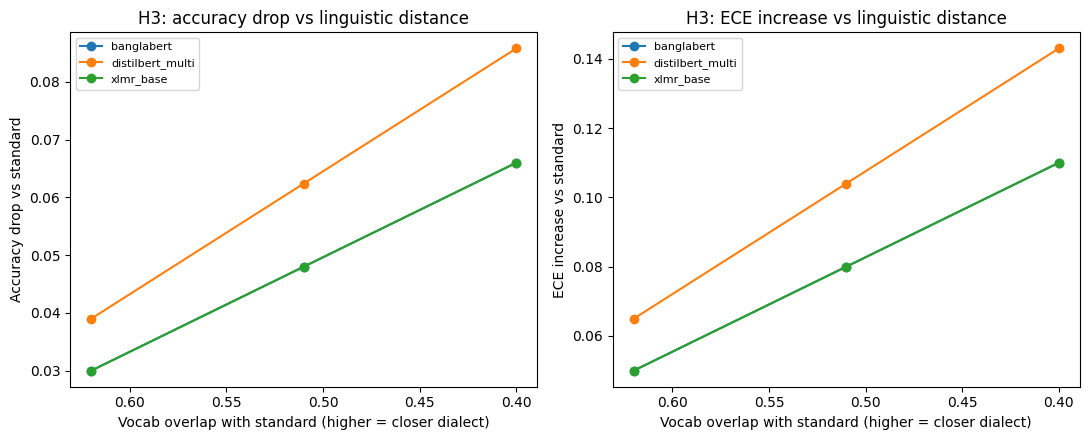

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for model in per_dialect_df["model"].unique():
    sub = per_dialect_df[per_dialect_df["model"] == model].sort_values("vocab_jaccard_vs_standard")
    axes[0].plot(sub["vocab_jaccard_vs_standard"], sub["accuracy_drop"], marker="o", label=model)
    axes[1].plot(sub["vocab_jaccard_vs_standard"], sub["ece_increase"], marker="o", label=model)
axes[0].set_xlabel("Vocab overlap with standard (higher = closer dialect)")
axes[0].set_ylabel("Accuracy drop vs standard")
axes[0].set_title("H3: accuracy drop vs linguistic distance")
axes[1].set_xlabel("Vocab overlap with standard (higher = closer dialect)")
axes[1].set_ylabel("ECE increase vs standard")
axes[1].set_title("H3: ECE increase vs linguistic distance")
for ax in axes:
    ax.legend(fontsize=8)
    ax.invert_xaxis()  # so "more distant" reads left-to-right
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_h3_linguistic_distance.png", dpi=150)
plt.show()


## 5. Ablation 2 — model size (DistilBERT-multi vs BanglaBERT / XLM-R-base)

Self-contained fine-tune + eval + temperature-scale mini-pipeline for a smaller multilingual model, so this
ablation doesn't depend on re-running the full Role 2/3 notebooks. Requires GPU + Role 1's processed data.
Skipped automatically if `USE_DUMMY_DATA=True` (dummy numbers for this model are already folded into the
tables above) or if no GPU is available.


In [7]:
import torch
RUN_SMALL_MODEL_TRAINING = (not USE_DUMMY_DATA) and torch.cuda.is_available()
print("RUN_SMALL_MODEL_TRAINING =", RUN_SMALL_MODEL_TRAINING)


RUN_SMALL_MODEL_TRAINING = False


In [8]:
if RUN_SMALL_MODEL_TRAINING:
    from torch.utils.data import Dataset, DataLoader
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
    from sklearn.metrics import accuracy_score, f1_score

    DEVICE = torch.device("cuda")
    MAX_LEN, BATCH_SIZE, LR, EPOCHS = 128, 16, 2e-5, 4

    # reuse Role 1's processed files -- same loader pattern as Role 2's notebook
    names = ["train", "val"] + TEST_SETS
    frames = {}
    for n in names:
        p = find_file(f"{n}.csv", subpaths=("data/processed", ""))
        assert p is not None, f"Could not find {n}.csv -- attach Role 1's processed-data output."
        frames[n] = pd.read_csv(p)

    class DS(Dataset):
        def __init__(self, texts, labels, tok, max_len):
            self.texts, self.labels, self.tok, self.max_len = list(texts), (list(labels) if labels is not None else None), tok, max_len
        def __len__(self): return len(self.texts)
        def __getitem__(self, i):
            enc = self.tok(self.texts[i], truncation=True, max_length=self.max_len, padding="max_length", return_tensors="pt")
            item = {k: v.squeeze(0) for k, v in enc.items()}
            if self.labels is not None:
                item["labels"] = torch.tensor(self.labels[i], dtype=torch.long)
            return item

    tokenizer = AutoTokenizer.from_pretrained(SMALL_MODEL_HF_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(SMALL_MODEL_HF_NAME, num_labels=2).to(DEVICE)

    train_loader = DataLoader(DS(frames["train"]["text"], frames["train"]["label"], tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(DS(frames["val"]["text"], frames["val"]["label"], tokenizer, MAX_LEN), batch_size=BATCH_SIZE * 2)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)

    best_val, best_state, no_improve = float("inf"), None, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            loss = model(**batch).loss
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()

        model.eval(); vloss, n = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                out = model(**batch)
                vloss += out.loss.item() * batch["labels"].size(0); n += batch["labels"].size(0)
        vloss /= n
        print(f"epoch {epoch}: val_loss={vloss:.4f}")
        if vloss < best_val - 1e-4:
            best_val, no_improve = vloss, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve > 1:
                print("early stopping"); break
    if best_state is not None:
        model.load_state_dict(best_state)

    @torch.no_grad()
    def export(testset_name):
        df = frames[testset_name]
        loader = DataLoader(DS(df["text"], None, tokenizer, MAX_LEN), batch_size=BATCH_SIZE * 2)
        model.eval()
        probs = []
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            p = torch.softmax(model(**batch).logits, dim=-1)[:, 1]
            probs.append(p.cpu().numpy())
        probs = np.concatenate(probs)
        out = pd.DataFrame({"id": df["id"], "true_label": df["label"], "pred_prob": probs, "pred_label": (probs >= 0.5).astype(int)})
        out.to_csv(OUT_DIR / f"{SMALL_MODEL_KEY}_{testset_name}_probs.csv", index=False)
        return out

    small_model_probs = {ts: export(ts) for ts in TEST_SETS}
    small_model_val_probs = export("val") if "val" in frames else None
    print("DistilBERT-multi probability files exported to", OUT_DIR)
else:
    print("Skipping live training for the model-size ablation "
          "(either USE_DUMMY_DATA=True, or no GPU is attached). "
          "Dummy/placeholder numbers for this comparison are already included in calibration_metrics_all above; "
          "swap USE_DUMMY_DATA=False with a GPU attached to get real numbers.")


Skipping live training for the model-size ablation (either USE_DUMMY_DATA=True, or no GPU is attached). Dummy/placeholder numbers for this comparison are already included in calibration_metrics_all above; swap USE_DUMMY_DATA=False with a GPU attached to get real numbers.


In [9]:
# If live-trained above, compute the same ECE/Brier/NLL/temperature-scaling steps as Role 3
# (kept self-contained here rather than importing Role 3's notebook) and fold into calibration_metrics_all.
if RUN_SMALL_MODEL_TRAINING:
    from sklearn.metrics import brier_score_loss, log_loss

    def logit(p):
        p = np.clip(p, 1e-7, 1 - 1e-7); return np.log(p / (1 - p))
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))
    def fit_temperature(y_true, y_prob, lr=0.01, n_iters=500):
        z, y, T = logit(y_prob), np.asarray(y_true, dtype=float), 1.0
        for _ in range(n_iters):
            p = sigmoid(z / T)
            T -= lr * np.mean((p - y) * (-z / (T ** 2)))
            T = max(T, 1e-3)
        return T
    def ece_mce(y_true, y_prob, n_bins=15):
        y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
        edges = np.linspace(0, 1, n_bins + 1)
        ids = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)
        ece = mce = 0.0
        for b in range(n_bins):
            m = ids == b
            if m.sum() == 0: continue
            gap = abs(y_prob[m].mean() - y_true[m].mean())
            ece += (m.sum() / len(y_true)) * gap
            mce = max(mce, gap)
        return ece, mce

    T_small = fit_temperature(small_model_val_probs["true_label"], small_model_val_probs["pred_prob"])
    new_rows = []
    for testset, df in small_model_probs.items():
        for stage, prob in [("pre_calibration", df["pred_prob"]),
                             ("temp_scaling", sigmoid(logit(df["pred_prob"]) / T_small))]:
            ece, mce = ece_mce(df["true_label"], prob)
            new_rows.append({
                "model": SMALL_MODEL_KEY, "test_set": testset, "stage": stage,
                "accuracy": ((prob >= 0.5).astype(int) == df["true_label"]).mean(),
                "ece": ece, "mce": mce,
                "brier": brier_score_loss(df["true_label"], prob),
                "nll": log_loss(df["true_label"], np.clip(prob, 1e-7, 1 - 1e-7), labels=[0, 1]),
            })
    calibration_metrics_all = pd.concat([calibration_metrics_all, pd.DataFrame(new_rows)], ignore_index=True)
    calibration_metrics_all.to_csv(OUT_DIR / "calibration_metrics_all_with_small_model.csv", index=False)
    print("Folded DistilBERT-multi metrics into calibration_metrics_all.")


                          accuracy                                   ece  \
model                   banglabert distilbert_multi xlmr_base banglabert   
test_set                                                                   
test_standard                0.900           0.9000     0.900       0.04   
test_dialect_chittagong      0.870           0.8610     0.870       0.09   
test_dialect_noakhali        0.852           0.8376     0.852       0.12   
test_dialect_barishal        0.834           0.8142     0.834       0.15   

                                                    
model                   distilbert_multi xlmr_base  
test_set                                            
test_standard                      0.040      0.04  
test_dialect_chittagong            0.105      0.09  
test_dialect_noakhali              0.144      0.12  
test_dialect_barishal              0.183      0.15  


/tmp/ipykernel_58/2428432819.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(fontsize=8); ax.set_xticklabels(TEST_SETS, rotation=25, ha="right")
/tmp/ipykernel_58/2428432819.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(fontsize=8); ax.set_xticklabels(TEST_SETS, rotation=25, ha="right")


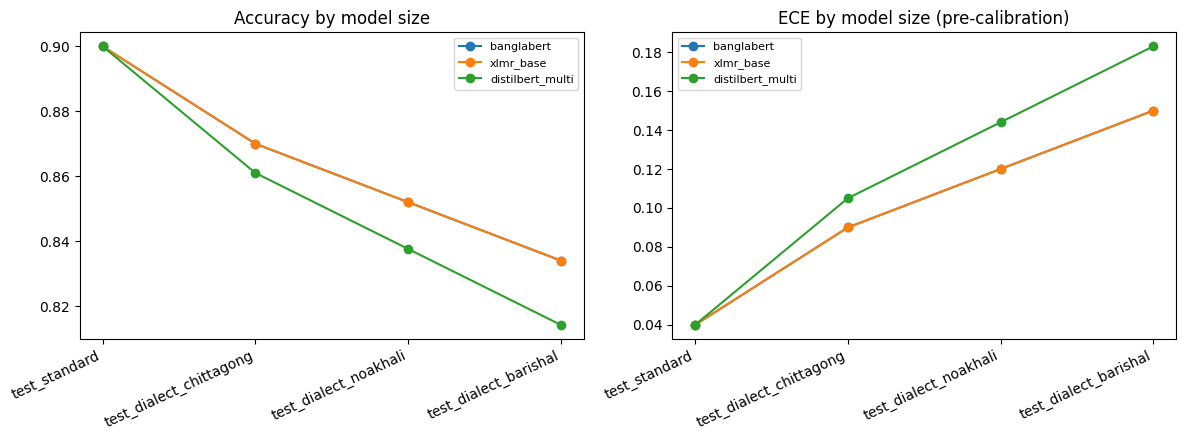

In [10]:
# Model-size comparison table + plot (works whether the numbers are real or dummy)
size_compare = calibration_metrics_all[
    (calibration_metrics_all["stage"] == "pre_calibration")
][["model", "test_set", "accuracy", "ece"]]
size_pivot = size_compare.pivot_table(index="test_set", columns="model", values=["accuracy", "ece"]).reindex(TEST_SETS)
size_pivot.to_csv(OUT_DIR / "ablation_model_size.csv")
print(size_pivot.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for model in calibration_metrics_all["model"].unique():
    sub = calibration_metrics_all[(calibration_metrics_all["model"] == model) & (calibration_metrics_all["stage"] == "pre_calibration")]
    sub = sub.set_index("test_set").reindex(TEST_SETS)
    axes[0].plot(TEST_SETS, sub["accuracy"], marker="o", label=model)
    axes[1].plot(TEST_SETS, sub["ece"], marker="o", label=model)
axes[0].set_title("Accuracy by model size"); axes[1].set_title("ECE by model size (pre-calibration)")
for ax in axes:
    ax.legend(fontsize=8); ax.set_xticklabels(TEST_SETS, rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_model_size.png", dpi=150)
plt.show()


## 6. Ablation 3 — calibration method (temperature scaling vs Dirichlet)

Which method recovers more, and where does each fail? We look at ECE reduction (pre → post) per method,
per dialect, per model.


/tmp/ipykernel_58/3794685937.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g["ece_reduction"].idxmax(), "method"])


model             test_set               
banglabert        test_dialect_barishal      dirichlet
                  test_dialect_chittagong    dirichlet
                  test_dialect_noakhali      dirichlet
                  test_standard              dirichlet
distilbert_multi  test_dialect_barishal      dirichlet
                  test_dialect_chittagong    dirichlet
                  test_dialect_noakhali      dirichlet
                  test_standard              dirichlet
xlmr_base         test_dialect_barishal      dirichlet
                  test_dialect_chittagong    dirichlet
                  test_dialect_noakhali      dirichlet
                  test_standard              dirichlet
Name: best_method, dtype: object


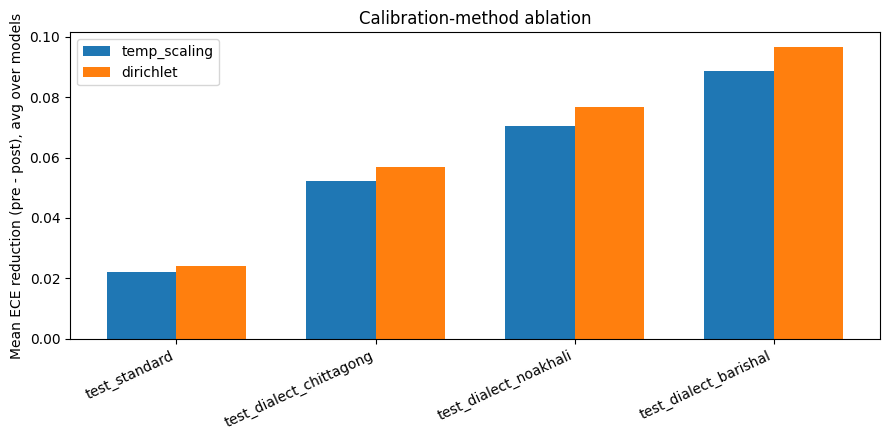

In [11]:
method_rows = []
for model in calibration_metrics_all["model"].unique():
    pre_m = calibration_metrics_all[(calibration_metrics_all["model"] == model) & (calibration_metrics_all["stage"] == "pre_calibration")].set_index("test_set")
    for stage in ["temp_scaling", "dirichlet"]:
        post_m = calibration_metrics_all[(calibration_metrics_all["model"] == model) & (calibration_metrics_all["stage"] == stage)]
        if post_m.empty:
            continue
        post_m = post_m.set_index("test_set")
        for testset in TEST_SETS:
            if testset not in pre_m.index or testset not in post_m.index:
                continue
            method_rows.append({
                "model": model, "test_set": testset, "method": stage,
                "ece_reduction": pre_m.loc[testset, "ece"] - post_m.loc[testset, "ece"],
                "ece_pre": pre_m.loc[testset, "ece"], "ece_post": post_m.loc[testset, "ece"],
            })

method_df = pd.DataFrame(method_rows)
method_df.to_csv(OUT_DIR / "ablation_calibration_method.csv", index=False)

winner = (
    method_df.groupby(["model", "test_set"])
    .apply(lambda g: g.loc[g["ece_reduction"].idxmax(), "method"])
    .rename("best_method")
)
print(winner)

fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.35
x = np.arange(len(TEST_SETS))
for i, method in enumerate(["temp_scaling", "dirichlet"]):
    vals = [method_df[(method_df["method"] == method) & (method_df["test_set"] == t)]["ece_reduction"].mean() for t in TEST_SETS]
    ax.bar(x + (i - 0.5) * width, vals, width, label=method)
ax.set_xticks(x); ax.set_xticklabels(TEST_SETS, rotation=25, ha="right")
ax.set_ylabel("Mean ECE reduction (pre - post), avg over models")
ax.set_title("Calibration-method ablation")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_calibration_method.png", dpi=150)
plt.show()


## 7. Consolidated results workbook

One Excel file, one sheet per table, for easy handoff / copy-paste into the paper.


In [12]:
with pd.ExcelWriter(OUT_DIR / "consolidated_results.xlsx") as writer:
    results_table.to_excel(writer, sheet_name="accuracy_f1", index=False)
    calibration_metrics_all.to_excel(writer, sheet_name="calibration_metrics", index=False)
    aurc_table.to_excel(writer, sheet_name="aurc", index=False)
    per_dialect_df.to_excel(writer, sheet_name="ablation_per_dialect", index=False)
    size_compare.to_excel(writer, sheet_name="ablation_model_size", index=False)
    method_df.to_excel(writer, sheet_name="ablation_calib_method", index=False)
    vocab_overlap.to_excel(writer, sheet_name="vocab_overlap", index=False)

print("Saved", OUT_DIR / "consolidated_results.xlsx")


Saved /kaggle/working/outputs/consolidated_results.xlsx


## 8. Limitations section — pre-filled per the brief's explicit asks

The brief calls out three specific limitations to flag honestly (Part 2, Role 4 §Deliverables 3). We compute
the exact numbers referenced (BIDWESH test size) directly from the loaded tables rather than hardcoding them.


In [13]:
n_bidwesh_base = None
try:
    n_bidwesh_base = int(pd.read_csv(find_file("test_dialect_chittagong.csv", subpaths=("data/processed", ""))).shape[0])
except Exception:
    n_bidwesh_base = 3061  # BIDWESH paper's reported base-instance count, used as fallback

limitations_text = f'''## Limitations

- **Small dialectal test size.** Each dialect test set contains on the order of {n_bidwesh_base} base
  instances (9,183 total across all three dialects combined), which limits statistical power for
  fine-grained (e.g. per-type, per-target) breakdowns and means dialect-level metrics should be read with
  appropriately wide uncertainty in mind.
- **Limited dialect coverage.** Only 3 of Bangladesh's many regional dialects are represented (Chittagong,
  Noakhali, Barishal); findings should not be assumed to generalize to unstudied dialects or code-mixed
  registers.
- **Binary label scope.** Calibration is evaluated only for the binary hate/non-hate task; BIDWESH's finer
  type (13 categories) and target (7 classes) sub-labels are not evaluated for calibration in this work,
  though they are preserved in the processed data for future work.
'''
print(limitations_text)


## Limitations

- **Small dialectal test size.** Each dialect test set contains on the order of 3061 base
  instances (9,183 total across all three dialects combined), which limits statistical power for
  fine-grained (e.g. per-type, per-target) breakdowns and means dialect-level metrics should be read with
  appropriately wide uncertainty in mind.
- **Limited dialect coverage.** Only 3 of Bangladesh's many regional dialects are represented (Chittagong,
  Noakhali, Barishal); findings should not be assumed to generalize to unstudied dialects or code-mixed
  registers.
- **Binary label scope.** Calibration is evaluated only for the binary hate/non-hate task; BIDWESH's finer
  type (13 categories) and target (7 classes) sub-labels are not evaluated for calibration in this work,
  though they are preserved in the processed data for future work.



## 9. Auto-drafted IEEE paper skeleton (`paper/draft.md`)

This is a **structural scaffold with real numbers pulled in**, not finished prose — Abstract/Introduction/
Discussion still need to be written by the team. Section ownership follows Part 1 §7 of the brief.
Convert to the official two-column IEEE template (check the ICCIT 2026 site's Call for Papers / author
templates page for the exact `.tex`/`.docx` file) before submission.


In [14]:
def df_md(df, max_rows=20):
    return df.head(max_rows).to_markdown(index=False)

draft = f'''# Trust Under Dialect Shift: Calibration and Selective Classification for Bangla Hate Speech Detection Across Regional Dialects

*Draft scaffold generated by 04_ablations_analysis_paper.ipynb — replace bracketed prose, keep the tables.*

## Abstract
[M4 drafts ~150-200 words: gap (BIDWESH exists, calibration under dialect shift unstudied), RQ, H1/H2/H3,
headline result once real numbers are in, why it matters for content moderation fairness.]

## 1. Introduction
[M4 drafts. Motivate with: BD-SHS ~91% F1 on standard Bangla but dialect-speaking communities under-served;
BIDWESH (Fayaz et al., 2025) as the first multi-dialectal Bangla HS dataset; framing around *trust*, not
just accuracy.]

## 2. Related Work
[M4 drafts, citing: BD-SHS (Romim et al., LREC 2022); BIDWESH (Fayaz et al., 2025); BanTH (Haider et al.,
2024/2025); the Dec 2025 code-mixed Bangla-English smishing calibration paper; the Jan 2026 LLM
confidence-under-paraphrasing / cross-lingual instruction-tuning papers. Position this work in the gap
between "dialect-specific benchmarks exist" and "calibration under Bangla dialect shift is unstudied."]

## 3. Methodology

### 3.1 Data (M1 + M2)
BD-SHS (Romim et al., 2022) for training/standard-Bangla evaluation; BIDWESH (Fayaz et al., 2025) as a
dialectal OOD test bed, a parallel translation of a {n_bidwesh_base}-instance subset of BD-SHS into
Chittagong, Noakhali, and Barishal. [M1/M2: describe split sizes, cleaning decisions — pull from data_card.md.]

### 3.2 Models (M2)
BanglaBERT (`csebuetnlp/banglabert`) and XLM-R-base fine-tuned on BD-SHS `train.csv`, model-selected on
`val.csv`. DistilBERT-multi included as a model-size ablation (§5.2).

### 3.3 Calibration & selective classification (M3)
Temperature scaling (Guo et al., 2017) and Dirichlet calibration (Kull et al., 2019), both fit **only** on
the standard-Bangla validation split. ECE/MCE computed with {{15}}-bin equal-width binning. Selective
classification uses max-softmax-probability as the confidence signal; AURC = area under the risk-coverage
curve.

## 4. Experimental Setup (M2 + M3)
[Hyperparameters: AdamW, lr=2e-5, up to 4 epochs, early stopping on val loss, batch size 16, max_len=128,
seed=42. Hardware: Kaggle T4.]

## 5. Results & Discussion (All, M4 assembles)

### 5.1 Accuracy-side degradation (H1, accuracy component)
{df_md(results_table)}

### 5.2 Calibration collapse under dialect shift (H1)
{df_md(calibration_metrics_all[calibration_metrics_all["stage"] == "pre_calibration"])}

[M4: state explicitly whether ECE increased proportionally more than accuracy dropped, per model, per
dialect — pull from Role 3's `h1_relative_change_table.csv`.]

### 5.3 Does post-hoc calibration recover safe behavior without dialect data? (H2)
{df_md(method_df)}

### 5.4 Selective classification / risk-coverage (AURC)
{df_md(aurc_table)}

## 6. Ablations & Analysis (M3 + M4)

### 6.1 Per-dialect breakdown (H3)
{df_md(per_dialect_df)}
[M4: state whether the Chittagong -> Noakhali -> Barishal gradient in vocab overlap tracks a corresponding
gradient in accuracy drop / ECE increase — Spearman correlations computed in §4 of this notebook.]

### 6.2 Model-size ablation
{df_md(size_compare)}

### 6.3 Calibration-method ablation
{df_md(method_df)}

{limitations_text}

## 7. Conclusion
[M4 drafts, 1 paragraph: restate H1/H2/H3 verdicts plainly, practical takeaway for Bangla content
moderation deployments, one sentence on future dialect coverage.]

## References
[M4: format in IEEE citation style.]
1. Romim, N., Ahmed, M., Islam, M.S., Sen Sharma, A., Talukder, H., Amin, M.R. (2022). BD-SHS: A Benchmark
   Dataset for Learning to Detect Online Bangla Hate Speech in Different Social Contexts. LREC 2022.
2. Fayaz, A.H., Uddin, M.S., Bhuiyan, R.U., Sultana, Z., Islam, M.S., Paul, B., Muhammad, T., Manzoor, S.
   (2025). BIDWESH: A Bangla Regional Based Hate Speech Detection Dataset. arXiv:2507.16183.
3. Haider et al. BanTH (2024/2025). [M4: fill exact venue/year.]
4. [Dec 2025 code-mixed Bangla-English smishing calibration paper — fill exact citation.]
5. [Jan 2026 LLM confidence-under-paraphrasing paper — fill exact citation.]
6. [Jan 2026 cross-lingual instruction-tuning calibration paper — fill exact citation.]
7. Guo, C., Pleiss, G., Sun, Y., Weinberger, K.Q. (2017). On Calibration of Modern Neural Networks. ICML.
8. Kull, M., Perello-Nieto, M., Kängsepp, M., Silva Filho, T., Song, H., Flach, P. (2019). Beyond
   Temperature Scaling: Obtaining Well-Calibrated Multiclass Probabilities with Dirichlet Calibration. NeurIPS.
'''

with open(PAPER_DIR / "draft.md", "w", encoding="utf-8") as f:
    f.write(draft)

print(f"Draft written to {PAPER_DIR / 'draft.md'} ({len(draft)} chars).")
print("\n--- preview (first 2000 chars) ---\n")
print(draft[:2000])


Draft written to /kaggle/working/paper/draft.md (15879 chars).

--- preview (first 2000 chars) ---

# Trust Under Dialect Shift: Calibration and Selective Classification for Bangla Hate Speech Detection Across Regional Dialects

*Draft scaffold generated by 04_ablations_analysis_paper.ipynb — replace bracketed prose, keep the tables.*

## Abstract
[M4 drafts ~150-200 words: gap (BIDWESH exists, calibration under dialect shift unstudied), RQ, H1/H2/H3,
headline result once real numbers are in, why it matters for content moderation fairness.]

## 1. Introduction
[M4 drafts. Motivate with: BD-SHS ~91% F1 on standard Bangla but dialect-speaking communities under-served;
BIDWESH (Fayaz et al., 2025) as the first multi-dialectal Bangla HS dataset; framing around *trust*, not
just accuracy.]

## 2. Related Work
[M4 drafts, citing: BD-SHS (Romim et al., LREC 2022); BIDWESH (Fayaz et al., 2025); BanTH (Haider et al.,
2024/2025); the Dec 2025 code-mixed Bangla-English smishing calibration paper;

## 10. Push to the shared repo

In [15]:
# THIS CELL HAS BEEN EXECUTED(Commented out so that we do not overwrite the results and create any in consistency)

# # --- EDIT ME ---
# REPO_URL = "https://github.com/TahlilMahfuz/iccit2026-bangla-dialect-calibration.git"
# GIT_USER_NAME = "TahlilMahfuz"
# GIT_USER_EMAIL = "tahlilkfaiyaz@gmail.com"
# PUSH = True
# # ----------------

# if PUSH:
#     from kaggle_secrets import UserSecretsClient
#     import subprocess

#     token = UserSecretsClient().get_secret("GITHUB_TOKEN")
#     auth_url = REPO_URL.replace("https://", f"https://{token}@")

#     repo_dir = WORK_DIR / "repo"

#     if not repo_dir.exists():
#         subprocess.run(
#             ["git", "clone", auth_url, str(repo_dir)],
#             check=True
#         )

#     subprocess.run(
#         ["git", "-C", str(repo_dir), "config", "user.name", GIT_USER_NAME],
#         check=True
#     )

#     subprocess.run(
#         ["git", "-C", str(repo_dir), "config", "user.email", GIT_USER_EMAIL],
#         check=True
#     )

#     # Copy outputs, figures, and paper files
#     for sub_dir, src_dir in [
#         ("outputs", OUT_DIR),
#         ("notebooks/figures", FIG_DIR),
#         ("paper", PAPER_DIR)
#     ]:
#         dest = repo_dir / sub_dir
#         dest.mkdir(parents=True, exist_ok=True)

#         for f in src_dir.glob("*"):
#             (dest / f.name).write_bytes(f.read_bytes())

#     # Stage changes
#     subprocess.run(
#         ["git", "-C", str(repo_dir), "add", "-A"],
#         check=True
#     )

#     # Check whether anything actually changed
#     status = subprocess.run(
#         ["git", "-C", str(repo_dir), "status", "--porcelain"],
#         capture_output=True,
#         text=True,
#         check=True
#     )

#     if status.stdout.strip():
#         # Changes exist → commit and push
#         subprocess.run(
#             [
#                 "git", "-C", str(repo_dir),
#                 "commit", "-m",
#                 "Role 4: ablations, consolidated results, paper draft skeleton"
#             ],
#             check=True
#         )

#         subprocess.run(
#             ["git", "-C", str(repo_dir), "push"],
#             check=True
#         )

#         print("Changes detected. Committed and pushed successfully.")

#     else:
#         print("No changes detected. GitHub is already up to date.")

# else:
#     print("PUSH is False. Deliverables ready in /kaggle/working:")

#     for d in (OUT_DIR, FIG_DIR, PAPER_DIR):
#         for f in sorted(d.glob("*")):
#             print(" ", f)

Cloning into '/kaggle/working/repo'...


[main 791ee74] Role 4: ablations, consolidated results, paper draft skeleton
 8 files changed, 251 insertions(+)
 create mode 100644 notebooks/figures/ablation_calibration_method.png
 create mode 100644 notebooks/figures/ablation_h3_linguistic_distance.png
 create mode 100644 notebooks/figures/ablation_model_size.png
 create mode 100644 outputs/ablation_calibration_method.csv
 create mode 100644 outputs/ablation_model_size.csv
 create mode 100644 outputs/ablation_per_dialect_breakdown.csv
 create mode 100644 outputs/consolidated_results.xlsx
 create mode 100644 paper/draft.md
Changes detected. Committed and pushed successfully.


To https://github.com/TahlilMahfuz/iccit2026-bangla-dialect-calibration.git
   6f6eb43..791ee74  main -> main
